# prep

In [1]:
account_path = '/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/'

In [2]:
# mount the drive
from google.colab import drive
drive.mount('/content/drive/')
from google.colab import auth
auth.authenticate_user()

# load packages - basics
!pip install pynrrd
import os
import csv
import numpy as np
import pandas as pd
import math
import time
import json
import nrrd

Mounted at /content/drive/


In [3]:
# load packages - stats
!pip install scikit-posthocs
import scipy
from scipy import io
from scipy.fftpack import rfft, irfft, fftfreq
import scipy.stats as stats
from scipy.stats import zscore

import statsmodels.api as sm
import statsmodels.formula.api as smf
import scikit_posthocs as scikit
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels

import random
from random import randrange, shuffle
import itertools
from itertools import combinations
import sklearn
from sklearn.decomposition import PCA, FastICA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score

In [4]:
# load packages - plotting and template settings
import matplotlib as mpl
from matplotlib import pyplot as plt
%matplotlib inline

from matplotlib.patches import Rectangle
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib import animation
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## fcn.

In [5]:
import gspread
from google.auth import default

def read_metadata(gsheet_url,tab_name):
  """This script reads information in a tab in the Google sheet, where metadata for each experiment is stored.
  """
  # import gspread
  # from google.auth import default

  # reading in google sheet with experimental details
  creds, _ = default()
  gc = gspread.authorize(creds)

  # insert URl of gsheet, specify worksheets as different variables
  wb = gc.open_by_url(gsheet_url)
  exps = wb.worksheet(tab_name)

  #
  all_data = pd.DataFrame(exps.get_all_records())
  metadata = all_data.set_index('experiment')
  display(all_data)

  return metadata

## config

In [6]:
# figures output parameters
mpl.rcParams['lines.linewidth'] = 1        # default line width
mpl.rcParams['patch.linewidth'] = 0
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

# Set global Matplotlib parameters for PDF output
mpl.rcParams['pdf.fonttype'] = 42          # Use TrueType fonts (editable text)

mpl.rcParams['figure.figsize'] = (4,3)     # Default figure size in inches
mpl.rcParams['axes.titlesize'] = 16        # Title font size
mpl.rcParams['axes.labelsize'] = 14        # Axis label font size
mpl.rcParams['xtick.labelsize'] = 10       # X-axis tick label size
mpl.rcParams['ytick.labelsize'] = 10       # Y-axis tick label size
mpl.rcParams['legend.fontsize'] = 8        # Legend font size
mpl.rcParams['savefig.dpi'] = 300          # DPI for high-quality export (relevant for raster elements)
mpl.rcParams['savefig.transparent'] = True # Ensures background is transparent
sns.set(style="white",font_scale=1)     # global scaling of all texts
mpl.rcParams['xtick.bottom'] = True        # make sure ticks visible
mpl.rcParams['ytick.left'] = True

mpl.rcParams['xtick.major.width'] = 0.5    # X-axis major tick width
mpl.rcParams['ytick.major.width'] = 0.5    # Y-axis major tick width
mpl.rcParams['axes.linewidth'] = 0.5       # Axis line width

from cycler import cycler
# remove red from the default colors
mpl.rcParams['axes.prop_cycle'] = cycler('color', ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])

In [7]:
figure_path = account_path + 'Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/'
csv_path = account_path + 'Yu_escape_paper/Manuscript/Figures/figures_v8/csvs/'

# Data: tap

In [8]:
# directories for the data and analysis
gsheet = 'https://docs.google.com/spreadsheets/d/1zJNHJJECC8FGB9S8tIh6QnoRihyoTZyKAgS-SE8ojwU/edit?gid=1421697431#gid=1421697431'
tab_name = 'tap_gsize'

experiment_class = 'Tap escape - group size'
path = account_path + 'Yu_escape_paper/Behavior/' + experiment_class
data_path = path + '/Data/'
save_path = path + '/Analysis/'

metadata = read_metadata(gsheet,tab_name)
experiments = metadata.index

,experiment,fish_num,rig_mm,vid_px
0,jjm_20240223_s0,1,350,959
1,jjm_20240223_s1,1,350,959
2,jjm_20240223_s2,1,350,959
3,jjm_20240223_s3,1,350,959
4,jjm_20240226_s0_redo0223,1,350,947
...,...,...,...,...
70,jjm_20240313_s10,8,350,975
71,jjm_20240313_s11,8,350,975
72,jjm_20240313_s12,8,350,975
73,jjm_20240321-2_s3,8,350,968


## group size color scheme

['#93c4de', '#4a97c9', '#1764ab', '#08306b']


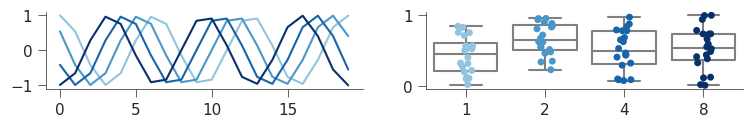

In [9]:
# RGB hex values theme - for summary stats plots
group_names = [1,2,4,8]; group_num = len(group_names)

# get the RGBA from normalized colormap axis
viridis_colors = [cm.Blues(i/(group_num+1)) for i in range(2,group_num+2)]
hex_colors = [f'#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}' for r, g, b, _ in viridis_colors] # Convert RGBA to HEX
print(hex_colors) # ['#abcfe5', '#6aadd5', '#3787c0', '#0f5ba3', '#08306b']

# validate colors settings work with both major plotting packages
plt.figure(figsize=[9,1]); plt.subplot(121);
for igs, gs in enumerate(group_names): plt.plot(np.cos(np.arange(igs,igs+20)),c=hex_colors[igs]);
tmp = {n: np.random.random(20) for n in group_names};
plt.subplot(122); sns.boxplot(data=tmp,fill=False,color='gray'); sns.stripplot(data=tmp,palette=hex_colors); sns.despine();
plt.show()

# S2a - tap escape setup

# S2b - example trajectory (4)


Group: jjm_20240313_s1 4 fish
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S2b


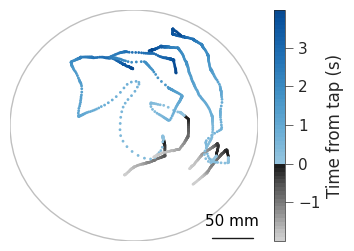

,f1_x,f1_y,f2_x,f2_y,f3_x,f3_y,f4_x,f4_y
0,738.156604,245.786887,723.977405,313.141760,462.151135,285.912347,579.439539,363.162683
1,741.264563,248.080588,726.176367,314.844781,462.269092,286.643976,582.627527,365.338580
2,744.606775,251.160739,727.730762,316.456470,463.063507,286.829248,585.074927,366.897314
3,748.586707,254.410074,728.684106,318.038800,465.272986,287.135645,587.555408,368.486371
4,752.658069,257.729816,730.174854,319.642926,467.814819,289.958344,590.621423,370.117664
...,...,...,...,...,...,...,...,...
358,681.328735,896.181531,571.754260,825.220117,492.645673,747.583545,668.464209,736.985327
359,683.082800,894.474475,570.091541,826.306641,492.700446,747.492542,668.685425,733.877661
360,685.414954,892.775159,566.969263,826.002600,492.732208,747.420801,668.827197,730.779346
361,687.136096,891.231726,563.883276,824.803027,493.983984,746.240540,668.737158,728.916223


In [ ]:
subpanel = 'S2b'
rep_experiments = ['jjm_20240313_s1'] # tap from lower left corner (top down view)
samples_x = []; samples_y = [] # for csv saving

for exp in rep_experiments:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'

  # load data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  fish_num, scale, fps, frame_num =  data['fish_num'], data['scale'], data['fps'], data['frame_num']
  f_speed, f_bodylength_mm = data['f_speed']*scale, data['f_bodylength_mm']
  f_x, f_y = data['f_x'], data['f_y']
  data = np.load(load_path + 'lev0_tap.npz', allow_pickle=True)
  tap = data['tap_frames'][0]

  print('\nGroup:', exp, fish_num, 'fish')
  # windows of plotting # 2+4 sec peri tap
  pre, post = 2, 4 # in sec before and after tap
  start = tap-int(pre*fps); stop = tap+int(post*fps)

  # trajectories # colored by time position
  fig, ax = plt.subplots(figsize=[4,3])
  ax.add_patch(plt.Circle((500,500),radius=500, edgecolor=(0,0,0,0.25), facecolor='none', linewidth=1))

  # Define custom hybrid colormap
  cmap1 = plt.colormaps['Greys']; cmap2 = plt.colormaps['Blues']
  colors = np.vstack((cmap1(np.linspace(0.3,0.9,20)), cmap2(np.linspace(0.4,0.9,40))))
  combined_cmap = mcolors.ListedColormap(colors);
  combined_time = (np.arange(start,stop)-tap)/fps

  for f in range(fish_num):
    plt.scatter(f_x[f][start:stop:2],f_y[f][start:stop:2],c=combined_time[::2],cmap=combined_cmap,s=1)
    samples_x.append(f_x[f][start:stop:2]);
    samples_y.append(f_y[f][start:stop:2])
  plt.colorbar(label='Time from tap (s)')

  plt.xlim(0,1000); plt.ylim(0,1000); plt.xticks([]); plt.yticks([])
  # scale bar
  x = np.arange(980-(1000/6),980); y = np.ones(len(x))*15
  plt.plot(x,y,c='k',linewidth=1);
  plt.text(np.mean(x), np.mean(y)+50,'50 mm', ha='center', fontsize=11, color='black')
  for spine in ax.spines.values(): spine.set_visible(False)
  print(figure_path+subpanel)
  plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
  plt.show()

# save source data into csv - for time series, save out the visible part
series_dict = {}
for i, (xx,yy) in enumerate(zip(samples_x,samples_y)):
  col_name = f"f{i+1}_x"; series_dict[col_name] = pd.Series(xx)
  col_name = f"f{i+1}_y"; series_dict[col_name] = pd.Series(yy)

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# S2c - Δspeed (4)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S2c


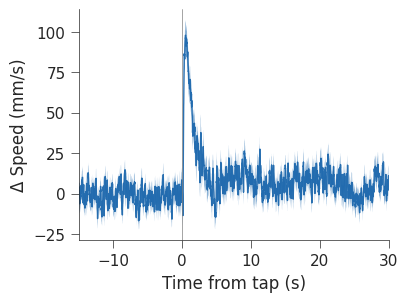

N = [15]


,fish_1,fish_2,fish_3,fish_4,fish_5,fish_6,fish_7,fish_8,fish_9,fish_10,...,fish_51,fish_52,fish_53,fish_54,fish_55,fish_56,fish_57,fish_58,fish_59,fish_60
0,-45.986031,7.749687,83.942508,-42.987607,-21.930917,-56.176766,50.853024,-39.771019,33.665034,-18.665914,...,-14.163747,-62.003089,19.542688,-29.429166,47.468818,83.959505,25.805746,77.045813,97.919776,3.265304
1,-44.835722,7.492871,98.068958,-42.862293,-21.184077,-56.418230,62.342197,-40.230188,55.569799,-2.116637,...,-8.566014,-43.938515,14.697413,-29.550242,62.352759,88.647964,5.756214,74.138485,114.519916,-17.142054
2,-44.718325,-12.759985,81.448911,-43.767243,-20.297734,-57.359632,74.849545,-21.748091,36.663493,-1.652452,...,-5.249796,-26.779658,15.213381,-29.079053,61.476134,89.388819,5.607560,70.124172,124.287889,-30.735323
3,-44.053232,-33.473345,64.855546,-43.878280,-20.193058,-57.118610,59.596193,1.979808,17.000000,15.195178,...,14.980265,-26.494349,34.410135,-9.390020,59.330989,72.264322,20.421798,51.124992,127.223694,-30.087111
4,-44.432162,-51.026403,58.603258,-44.363928,-18.919076,-56.412375,60.208267,28.657974,15.944789,13.483197,...,36.938978,-26.430012,35.377900,11.113489,59.669869,87.497152,29.260181,35.181727,127.364596,-22.435958
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5440,19.990943,18.336489,-56.170988,12.633477,98.560150,48.803972,11.415083,5.747028,-10.020241,-51.584095,...,7.978459,127.324282,49.080250,-31.040965,-13.031015,-31.568704,5.571284,-33.885993,-62.353047,-5.197546
5441,2.749913,17.591629,-56.492342,0.250453,88.846346,47.919107,11.954185,5.499367,17.444143,-52.493316,...,-10.073013,111.695135,48.883907,-32.904552,-11.788599,-16.900973,-5.681642,-35.159525,-78.362719,-29.688517
5442,3.085544,16.789422,-56.977930,2.412131,86.464005,47.728992,32.458953,-13.502045,15.566554,-52.002952,...,-11.661695,110.053783,48.411114,-34.252996,8.975622,-1.511474,-12.351501,-39.140556,-92.515808,-53.850036
5443,2.998215,-7.258318,-57.749946,3.259943,66.402403,67.869854,32.659465,-32.773715,43.870853,-51.748479,...,-14.309897,95.798832,46.393600,-34.867188,31.399338,-0.638883,-8.545934,-41.494848,-107.074798,-56.059297


In [ ]:
subpanel = 'S2c'
group_sizes = [4]; group_values = {n: [] for n in group_sizes}
hex_colors = ['#1764ab']

for exp in experiments[::]:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp];
  if fish_num not in group_sizes: continue

  # load data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  scale = data['scale']
  f_speed = data['f_speed']*scale
  data = np.load(load_path + 'lev0_tap.npz', allow_pickle=True)
  tap = data['tap_frames'][0]

  # get 30-sec x(121 fps) before and after tap get same legnth of arrays
  for f in range(fish_num):
    group_values[fish_num].append((f_speed[f][tap-int(30*121):tap+int(30*121)])-np.mean(f_speed[f][tap-int(30*121):tap]))

# make time_sec relative to tap for plotting
pre = np.linspace(-30,0,30*121); post = np.linspace(0,30,30*121)
rel_time = np.concatenate((pre,post)); rel_sec = np.round(rel_time,2)

# PLOT # mean+sem
plt.figure(figsize=[4,3])
for i, gs in enumerate(group_sizes):
  plt.plot(rel_sec,np.mean(group_values[gs],axis=0),linewidth=1,alpha=0.9, label=f'group of {gs}', color=hex_colors[i])
  plt.fill_between(rel_sec,np.mean(group_values[gs],axis=0)-stats.sem(group_values[gs],axis=0,nan_policy='omit'), \
                  np.nanmean(group_values[gs],axis=0)+stats.sem(group_values[gs],axis=0, nan_policy='omit'),alpha=0.5, color=hex_colors[i],linewidth=0)

plt.axvline(0,c='grey',linewidth=0.5);
plt.xlim(-15,30);
plt.xlabel('Time from tap (s)'); plt.ylabel('Δ Speed (mm/s)')
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight');
plt.show()

print(f"N = {[int(len(group_values[g])/g) for g in group_sizes]}")

# save source data into csv - for time series, save out the visible part
ST, ED = -30, 30; st, ed = -15, 30; fps = 121

series_dict = {}
for group, samples in group_values.items():
  for i, sample in enumerate(samples):
    col_name = f"fish_{i+1}"
    series_dict[col_name] = pd.Series(sample[(st-ST)*fps:(ed-ST)*fps])  # auto-fills NaN

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# S2d - Δspeed time series (1 vs 4)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S2d


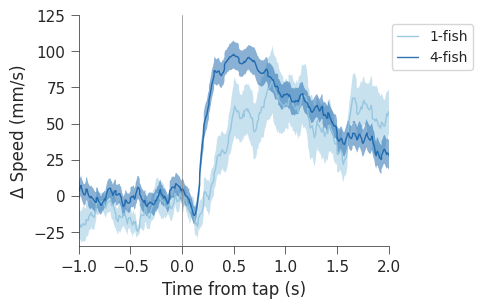

N = [15, 15]


,1fish_1,1fish_2,1fish_3,1fish_4,1fish_5,1fish_6,1fish_7,1fish_8,1fish_9,1fish_10,...,4fish_51,4fish_52,4fish_53,4fish_54,4fish_55,4fish_56,4fish_57,4fish_58,4fish_59,4fish_60
0,-47.152712,26.693348,-87.228463,-4.490079,-69.698324,-42.097277,-14.674042,-14.001063,79.654069,-14.071944,...,-31.320071,-61.097370,-35.585800,13.347818,44.680034,27.107736,-21.503196,0.567631,-20.880344,2.120954
1,-45.401343,7.974771,-86.763038,-3.305212,-69.379659,-41.989208,-14.202714,-14.653450,84.523538,-14.136705,...,-11.805705,-60.252736,-16.422467,12.228325,47.314062,44.667432,-18.437410,-0.611308,2.438050,19.995727
2,-45.534713,-8.902028,-83.154913,-22.140002,-68.598284,-41.717263,-13.356894,-14.213474,104.118024,-14.198820,...,-11.186846,-59.820449,2.884500,11.867097,48.468318,62.932544,-2.717965,-0.417732,27.602803,22.706323
3,-44.549998,-23.937048,-83.568824,-21.237297,-68.543715,-41.717772,-12.567261,-15.020178,107.508224,-14.172034,...,-26.934587,-60.471489,2.901221,11.395868,46.368637,83.605708,-10.499357,0.873141,31.172455,23.211862
4,-42.703001,-40.094702,-83.269929,-21.196774,-68.453955,-41.514983,-12.436000,-15.107936,109.299652,-14.194003,...,-26.895547,-60.923079,3.719285,-6.943862,27.143313,100.129240,-21.764769,3.459549,32.486971,38.309854
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,0.430908,81.842205,26.986277,-20.249474,28.985071,-39.532093,-18.209554,32.588300,116.661639,-7.375157,...,36.531568,-28.843145,-68.144124,109.515155,-89.569702,-50.714825,-95.878005,1.801175,22.860203,47.020358
359,-18.604216,83.059283,44.790204,-23.126222,30.377066,-41.055849,0.755724,33.046508,115.383591,7.707812,...,27.297778,-29.564981,-40.870783,97.421522,-90.008822,-67.633251,-112.399491,0.011976,9.025926,18.971262
360,-19.036318,84.276360,28.220156,-9.963959,30.362954,-42.315352,20.484303,49.173001,113.470615,8.924025,...,18.063988,-30.011578,-13.544244,111.973483,-89.800586,-68.441446,-112.224106,0.970252,-9.703735,-7.148272
361,-29.406158,84.210252,25.699533,-8.631667,47.337136,-41.847247,23.251374,49.354837,93.681912,25.033912,...,23.576927,-30.450645,-14.905242,126.420567,-90.263300,-70.065227,-112.307316,-14.966440,-30.276146,-8.440146


In [ ]:
subpanel = 'S2d'
group_sizes = [1,4]; group_values = {n: [] for n in group_sizes}
hex_colors = ['#93c4de', '#1764ab']

for exp in experiments[::]:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp];
  if fish_num not in group_sizes: continue

  # load data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  scale, f_bodylength_mm = data['scale'], data['f_bodylength_mm']
  f_speed = data['f_speed']*scale
  data = np.load(load_path + 'lev0_tap.npz', allow_pickle=True)
  tap = data['tap_frames'][0]

  # get 30-sec x(121 fps) before and after tap get same legnth of arrays
  for f in range(fish_num):
    # subtract baseline (30-sec pre tap) to get change of speed
    group_values[fish_num].append((f_speed[f][tap-int(30*121):tap+int(30*121)])-np.mean(f_speed[f][tap-int(30*121):tap]))


# make time_sec relative to tap for plotting
pre = np.linspace(-30,0,30*121); post = np.linspace(0,30,30*121)
rel_time = np.concatenate((pre,post)); rel_sec = np.round(rel_time,2)

# PLOT # mean+sem
plt.figure(figsize=[4,3])
for i, gs in enumerate(group_sizes):
  plt.plot(rel_sec,np.mean(group_values[gs],axis=0),linewidth=1,alpha=0.9, label=f'{gs}-fish', color=hex_colors[i])
  plt.fill_between(rel_sec,np.mean(group_values[gs],axis=0)-stats.sem(group_values[gs],axis=0,nan_policy='omit'), \
                  np.nanmean(group_values[gs],axis=0)+stats.sem(group_values[gs],axis=0, nan_policy='omit'),alpha=0.5, color=hex_colors[i],linewidth=0)

plt.axvline(0,c='grey',linewidth=0.5);
plt.legend(bbox_to_anchor=(1,0.75),handlelength=1.5,markerscale=0.7,borderaxespad=0.2,fontsize=10)
plt.xlim(-1,2); plt.ylim(-35,125)
plt.xlabel('Time from tap (s)'); plt.ylabel('Δ Speed (mm/s)')
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight');
plt.show()

print(f"N = {[int(len(group_values[g])/g) for g in group_sizes]}")

# save source data into csv - for time series, save out the visible part
ST, ED = -30, 30; st, ed = -1, 2; fps = 121

series_dict = {}
for group, samples in group_values.items():
  for i, sample in enumerate(samples):
    col_name = f"{group}fish_{i+1}"
    series_dict[col_name] = pd.Series(sample[(st-ST)*fps:(ed-ST)*fps])  # auto-fills NaN

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# S2e - Δspeed stats (1 vs 4)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S2e


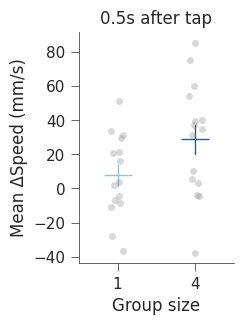

Ns, means, and  sems for data:
1: (N=15) 7.706, 6.304
4: (N=15) 28.796, 8.596

Normality test (Shapiro-Wilk):
Group 1: W = 0.977, p = 0.948
Group 4: W = 0.974, p = 0.916
all groups are normally distributed → use parametric test.

T-test: t = -1.978, p = 0.05780


,1fish,4fish
0,16.105130,85.655763
1,-4.660204,40.118199
2,-36.874917,60.372003
3,-6.824014,37.299337
4,51.286011,-4.289804
5,-27.694772,31.361042
6,2.285642,54.154328
7,-8.618908,-37.771985
8,21.241007,5.645471
9,-11.116209,3.124047


In [ ]:
subpanel = 'S2e'
window_of_interest = [0.5] # sec

for woi in window_of_interest:
  # DATA
  group_sizes = [1,4]; group_values = {n: [] for n in group_sizes}
  hex_colors = ['#93c4de', '#1764ab']

  escp_threshold = 1
  for exp in experiments[::]:
    load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
    fish_num = metadata.fish_num[exp];
    if fish_num not in group_sizes: continue

    # load data
    data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
    fps, scale = data['fps'], data['scale']
    f_speed =  data['f_speed']*scale
    data = np.load(load_path + 'lev0_tap.npz', allow_pickle=True)
    tap = data['tap_frames'][0]

    # compare pre and post tap 500-ms
    window = int(fps*woi)

    pre_speeds = [np.random.choice(i[:tap], size=window, replace=False) for i in f_speed]
    post_speeds = [i[tap:tap+window] for i in f_speed]

    if fish_num == 1:
      group_values[fish_num].append(np.nanmean(post_speeds[0])-np.nanmean(pre_speeds[0]))
    else:
      # randomly pull one from the group
      rng = np.random.default_rng(seed=39)
      f = rng.choice(np.arange(fish_num))
      group_values[fish_num].append((np.nanmean(post_speeds[f])-np.nanmean(pre_speeds[f])))

  # plot
  plt.figure(figsize=[2,3])
  sns.stripplot(data=group_values,color='gray',alpha=0.3,size=5)
  sns.pointplot(data=group_values,palette=hex_colors,linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);
  plt.xlabel('Group size'); plt.ylabel(f'Mean ΔSpeed (mm/s)')
  sns.despine(); plt.title(f'{woi}s after tap')
  print(figure_path+subpanel)
  plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight');
  plt.show()

  # stats
  group_sizes = list(group_values.keys())
  groups = group_values.keys()
  summary_data = group_values.values()
  print("Ns, means, and  sems for data:")
  for id, s in enumerate(summary_data):
    print(f'{group_sizes[id]}: (N={len(s)}) {np.nanmean(s):.3f}, {scipy.stats.sem(s):.3f}')

  ## -- 1. Test for normality in each group -- ##
  print("\nNormality test (Shapiro-Wilk):")
  normality_results = {}
  for group, data in zip(groups, summary_data):
    stat, p = stats.shapiro(data)
    normality_results[group] = {'W': stat, 'p': p}
  for g, res in normality_results.items():
    print(f"Group {g}: W = {res['W']:.3f}, p = {res['p']:.3f}")

  is_normal = all(res['p'] > 0.05 for res in normality_results.values());
  if is_normal: print("all groups are normally distributed \u2192 use parametric test.")
  else: print("not all groups are normally distributed \u2192 use nonparametric test.")

  ## -- 2. Group comparisons (& post hoc test) -- ##
  unique_groups = len(groups); annotation_dict = {}
  if unique_groups == 2:
    groups = list(groups); summary_data = group_values
    #  Two groups: t-test or Mann-Whitney
    if is_normal:
      stat, p = stats.ttest_ind(summary_data[groups[0]], summary_data[groups[1]])
      print(f"\nT-test: t = {stat:.3f}, p = {p:.5f}")
    else:
      stat, p = stats.mannwhitneyu(summary_data[groups[0]], summary_data[groups[1]])
      print(f"\nMann-Whitney U: U = {stat:.3f}, p = {p:.5f}")

  elif unique_groups > 2:
    if is_normal: # One-way ANOVA
      summary_data = list(group_values.values())
      groups = list(group_values.keys())
      df = pd.DataFrame({'data': np.concatenate(summary_data), 'group': np.repeat(groups, [len(d) for d in summary_data])})
      # Define the formula
      formula = 'data ~ group'
      # Fit the model
      model = smf.ols(formula, data=df).fit()
      anova_table = sm.stats.anova_lm(model, typ=2)
      print("\nOne-way ANOVA:\n", anova_table)
      if anova_table['PR(>F)'][0] < 0.05:
        flat_data = [val for sublist in summary_data for val in sublist]
        groups = [group_names[i] for i, sublist in enumerate(summary_data) for _ in sublist]
        tukey = pairwise_tukeyhsd(endog=flat_data, groups=groups, alpha=0.05)
        print("\nTukey's HSD post hoc test:\n", tukey.summary())
        for res in tukey._results_table.data[1:]:
          g1, g2, p = res[0], res[1], res[4]

    else: # Kruskal-Wallis test
      stat, p = stats.kruskal(*summary_data)
      print(f"\nKruskal-Wallis H-test: H = {stat:.3f}, p = {p:.5f}")
      if p < 0.05:
        # Dunn's post hoc test with Bonferroni correction
        data_for_dunn = list(summary_data); group_for_dunn = list(groups)
        dunn = scikit.posthoc_dunn(data_for_dunn, p_adjust='bonferroni')
        print("\nDunn's post hoc test with bonferroni correction: ",group_for_dunn)
        print(dunn)

  # save source data into csv
  series_dict = {}
  for key, values in group_values.items(): series_dict[f'{key}fish'] = pd.Series(values)

  df = pd.DataFrame(series_dict)
  display(df)
  df.to_csv(csv_path+subpanel+f'.csv', index=False)

# S2f - baseline speed stats (1 vs 4)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S2f


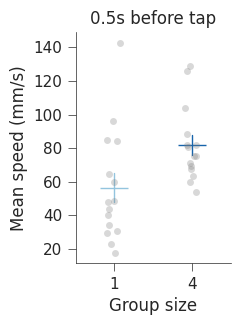

Ns, means, and  sems for data:
1: (N=15) 56.518, 8.666
4: (N=15) 81.816, 5.707

Normality test (Shapiro-Wilk):
Group 1: W = 0.892, p = 0.072
Group 4: W = 0.872, p = 0.037
not all groups are normally distributed → use nonparametric test.

Mann-Whitney U: U = 53.000, p = 0.01440


,1fish,4fish
0,64.733741,71.302416
1,84.366457,75.353114
2,96.227213,81.736649
3,84.794237,69.398881
4,59.551825,80.654959
5,40.305517,75.150745
6,30.863207,60.095693
7,17.649644,63.127813
8,29.458445,53.941703
9,22.712590,67.611829


In [ ]:
subpanel = 'S2f'
window_of_interest = [0.5] # sec

for woi in window_of_interest:
  # DATA
  group_sizes = [1,4]; group_values = {n: [] for n in group_sizes}
  hex_colors = ['#93c4de', '#1764ab']

  escp_threshold = 1
  for exp in experiments[::]:
    load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
    fish_num = metadata.fish_num[exp];
    if fish_num !=1 and fish_num !=4: continue

    # load data
    data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
    fps, scale = data['fps'], data['scale']
    f_speed =  data['f_speed']*scale
    data = np.load(load_path + 'lev0_tap.npz', allow_pickle=True)
    tap = data['tap_frames'][0]

    # compare pre and post tap 500-ms
    window = int(fps*woi)

    pre_speeds = [np.random.choice(i[:tap], size=window, replace=False) for i in f_speed]
    post_speeds = [i[tap:tap+window] for i in f_speed]

    # get mean of the group if n>1
    if fish_num == 1:
      group_values[fish_num].append(np.nanmean(pre_speeds[0]))
    else:
      group_values[fish_num].append(np.mean([(np.nanmean(pre_speeds[f])) for f in range(fish_num)]))

  # plot
  plt.figure(figsize=[2,3])
  sns.stripplot(data=group_values,color='gray',alpha=0.3,size=5)
  sns.pointplot(data=group_values,palette=hex_colors,linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);
  plt.xlabel('Group size'); plt.ylabel(f'Mean speed (mm/s)')
  sns.despine(); plt.title(f'{woi}s before tap')
  print(figure_path+subpanel)
  plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight');
  plt.show()

  # stats
  group_sizes = list(group_values.keys())
  groups = group_values.keys()
  summary_data = group_values.values()
  print("Ns, means, and  sems for data:")
  for id, s in enumerate(summary_data):
    print(f'{group_sizes[id]}: (N={len(s)}) {np.nanmean(s):.3f}, {scipy.stats.sem(s):.3f}')

  ## -- 1. Test for normality in each group -- ##
  print("\nNormality test (Shapiro-Wilk):")
  normality_results = {}
  for group, data in zip(groups, summary_data):
    stat, p = stats.shapiro(data)
    normality_results[group] = {'W': stat, 'p': p}
  for g, res in normality_results.items():
    print(f"Group {g}: W = {res['W']:.3f}, p = {res['p']:.3f}")

  is_normal = all(res['p'] > 0.05 for res in normality_results.values());
  if is_normal: print("all groups are normally distributed \u2192 use parametric test.")
  else: print("not all groups are normally distributed \u2192 use nonparametric test.")

  ## -- 2. Group comparisons (& post hoc test) -- ##
  unique_groups = len(groups); annotation_dict = {}
  if unique_groups == 2:
    groups = list(groups); summary_data = group_values
    #  Two groups: t-test or Mann-Whitney
    if is_normal:
      stat, p = stats.ttest_ind(summary_data[groups[0]], summary_data[groups[1]])
      print(f"\nT-test: t = {stat:.3f}, p = {p:.5f}")
    else:
      stat, p = stats.mannwhitneyu(summary_data[groups[0]], summary_data[groups[1]])
      print(f"\nMann-Whitney U: U = {stat:.3f}, p = {p:.5f}")

  elif unique_groups > 2:
    if is_normal: # One-way ANOVA
      summary_data = list(group_values.values())
      groups = list(group_values.keys())
      df = pd.DataFrame({'data': np.concatenate(summary_data), 'group': np.repeat(groups, [len(d) for d in summary_data])})
      # Define the formula
      formula = 'data ~ group'
      # Fit the model
      model = smf.ols(formula, data=df).fit()
      anova_table = sm.stats.anova_lm(model, typ=2)
      print("\nOne-way ANOVA:\n", anova_table)
      if anova_table['PR(>F)'][0] < 0.05:
        flat_data = [val for sublist in summary_data for val in sublist]
        groups = [group_names[i] for i, sublist in enumerate(summary_data) for _ in sublist]
        tukey = pairwise_tukeyhsd(endog=flat_data, groups=groups, alpha=0.05)
        print("\nTukey's HSD post hoc test:\n", tukey.summary())
        for res in tukey._results_table.data[1:]:
          g1, g2, p = res[0], res[1], res[4]

    else: # Kruskal-Wallis test
      stat, p = stats.kruskal(*summary_data)
      print(f"\nKruskal-Wallis H-test: H = {stat:.3f}, p = {p:.5f}")
      if p < 0.05:
        # Dunn's post hoc test with Bonferroni correction
        data_for_dunn = list(summary_data); group_for_dunn = list(groups)
        dunn = scikit.posthoc_dunn(data_for_dunn, p_adjust='bonferroni')
        print("\nDunn's post hoc test with bonferroni correction: ",group_for_dunn)
        print(dunn)

  # save source data into csv
  series_dict = {}
  for key, values in group_values.items(): series_dict[f'{key}fish'] = pd.Series(values)

  df = pd.DataFrame(series_dict)
  display(df)
  df.to_csv(csv_path+subpanel+f'.csv', index=False)

# S2g+h

In [10]:
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

In [11]:
# collect all swimming speed of 30-sec before tap
group_sizes = [1,4]; group_values = {n: [] for n in group_sizes}

dt_sec = 0.05  # sampling interval for delta heading
fps = 121      # frames per second (adjust as needed)
sliding_window = 5 # frames to smooth data

# stimulus-relative windows (in sec)
window_times = {'baseline': (-30, 0)}

# prepare pooling structure
group_sizes = [1, 4]  # example
pooled_speeds = {g: {w: [] for w in window_times} for g in group_sizes}

for exp in experiments:
  load_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp]
  if fish_num not in group_sizes: continue

  # load heading data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  scale = data['scale']
  f_speed = data['f_speed']*scale  # shape: fish_num x frame_num

  # load stimulus frame
  data = np.load(load_path + 'lev0_tap.npz', allow_pickle=True)
  tap_frame = data['tap_frames'][0]

  # use sliding window max
  speed_win = np.array([[np.max(speed[i:i + sliding_window])
            for i in range(len(speed) - sliding_window + 1)] for speed in f_speed])

  # loop over windows
  for w_name, (t_start, t_end) in window_times.items():
    # compute start and stop frame indices relative to tap
    i0 = tap_frame + int(t_start * fps)
    i1 = tap_frame + int(t_end * fps)
    if i1>i0:
      [pooled_speeds[fish_num][w_name].append(speed[i0:i1]) for speed in speed_win]

# concatenate across experiments
for g in pooled_speeds:
  for w_name, _ in window_times.items():
    if pooled_speeds[g][w_name]:  # avoid empty lists
      pooled_speeds[g][w_name] = np.concatenate(pooled_speeds[g][w_name])
    else:
      pooled_speeds[g][w_name] = np.array([])

# run test to see if two samples come from the same continuous distribution
g1, g2 = [g for g in group_sizes]
x = np.array(pooled_speeds[g1]['baseline'])
y = np.array(pooled_speeds[g2]['baseline'])

x = x[np.isfinite(x)]
y = y[np.isfinite(y)]

stat, p = stats.ks_2samp(x, y)
print(f"KS test: D = {stat:.3f}, p = {p:.3e}")

if p > 0.05:
  print("The distributions are the same, pool distribution.")
else:
  print("The distributions are different, do not pool distribution.")

KS test: D = 0.207, p = 0.000e+00
The distributions are different, do not pool distribution.


## S2g - Gaussian fitting of baseline speed

1 fish:
Means: [  3.45296996  53.21405817 113.55388112 188.56707194]
Covariances: [   2.97587113  541.1050818   693.31403284 1995.52396671]
Weights: [0.26122666 0.37538769 0.29132574 0.0720599 ]
4 fish:
Means: [  4.76033262  60.05885909 115.18397014 180.69630122]
Covariances: [  13.60342217  486.82106085  620.79230603 1244.50172102]
Weights: [0.11410075 0.37849023 0.34486689 0.16254213]
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/S2g


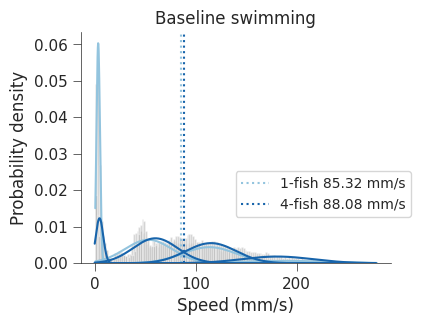

,1fish_data,1fish_means,1fish_stds,1fish_weights,1fish_escape_threshold,4fish_data,4fish_means,4fish_stds,4fish_weights,4fish_escape_threshold
0,55.404841,3.452970,1.725071,0.261227,85.318501,77.144907,4.760333,3.688282,0.114101,88.07827
1,55.404841,53.214058,23.261665,0.375388,NaN,77.144907,60.058859,22.064022,0.378490,NaN
2,55.404841,113.553881,26.330857,0.291326,NaN,60.095263,115.183970,24.915704,0.344867,NaN
3,55.404841,188.567072,44.671288,0.072060,NaN,77.298792,180.696301,35.277496,0.162542,NaN
4,53.496381,NaN,NaN,NaN,NaN,77.298792,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
217795,NaN,NaN,NaN,NaN,NaN,114.440735,NaN,NaN,NaN,NaN
217796,NaN,NaN,NaN,NaN,NaN,114.440735,NaN,NaN,NaN,NaN
217797,NaN,NaN,NaN,NaN,NaN,114.440735,NaN,NaN,NaN,NaN
217798,NaN,NaN,NaN,NaN,NaN,114.440735,NaN,NaN,NaN,NaN


In [12]:
subpanel = 'S2g'
hex_colors = ['#93c4de', '#1764ab']

# fit Gaussian separately
k_component = 4
cv_type = 'diag'
baseline_gaussian_df = {g: {} for g in group_sizes}

for g in group_sizes:
  swims=np.array(pooled_speeds[g]['baseline']) # inputs

  # Fit a GMM
  gmm = GaussianMixture(n_components=k_component, n_init=20, covariance_type=cv_type, \
                        random_state=42, reg_covar=1e-3)
  swims = swims.reshape(-1, 1)  # Reshape for GMM input
  gmm.fit(swims)

  # Get the means, covariances, and weights of the Gaussians
  means = gmm.means_.flatten()  # Means of the Gaussian components
  covariances = gmm.covariances_.flatten()  # Covariances (assuming diagonal)
  weights = gmm.weights_  # Weights of the Gaussian components
  # Get the probability that each value in swims belongs to each Gaussian
  probabilities = gmm.predict_proba(swims)

  # sort the component
  sort_idx = np.argsort(means)
  means = means[sort_idx]
  covariances = covariances[sort_idx] # change if not covariance_type != diag
  weights = weights[sort_idx]
  probabilities = probabilities[:, sort_idx]
  stds = np.sqrt(covariances)

  print(f'{g} fish:')
  print(f'Means: {means}'); print(f'Covariances: {covariances}'); print(f'Weights: {weights}')

  # save in df for future references
  baseline_gaussian_df[g]['data'] = swims
  baseline_gaussian_df[g]['means'] = means
  baseline_gaussian_df[g]['stds'] = stds
  baseline_gaussian_df[g]['weights'] = weights
  baseline_gaussian_df[g]['probabilities'] = probabilities

# visualize Gaussian cruves and threshold
plt.figure(figsize=(4,3))
for ig,g in enumerate(group_sizes):
  # load gaussian fit
  data, means, stds, weights =  baseline_gaussian_df[g]['data'], baseline_gaussian_df[g]['means'], \
  baseline_gaussian_df[g]['stds'], baseline_gaussian_df[g]['weights']
  # Mark the threshold
  m1, s1, w1 = means[1], stds[1], weights[1]
  m2, s2, w2 = means[2], stds[2], weights[2]

  # Solve w1*N(x|m1,s1) = w2*N(x|m2,s2)
  a = 1/(2*s1**2) - 1/(2*s2**2)
  b = m2/(s2**2) - m1/(s1**2)
  c = (m1**2)/(2*s1**2) - (m2**2)/(2*s2**2) + np.log((w2*s1)/(w1*s2))

  roots = np.roots([a, b, c])
  escape_threshold = np.max(roots.real)  # pick the higher-speed crossing
  baseline_gaussian_df[g]['escape_threshold'] = escape_threshold

  plt.hist(data.ravel(), bins=150, density=True, alpha=0.4, color='gray')
  x = np.linspace(data.ravel().min(), data.ravel().max(), 1000)
  for k in range(len(means)):
      plt.plot(x, weights[k] * norm.pdf(x, means[k], stds[k]), color=hex_colors[ig])
  plt.axvline(escape_threshold, color=hex_colors[ig],ls=':',label=f'{g}-fish {escape_threshold:.2f} mm/s')

plt.legend(loc=[0.5,0.2],fontsize=10); plt.title(f'Baseline swimming')
plt.xlabel("Speed (mm/s)"); plt.ylabel("Probability density")
sns.despine();
print(figure_path+subpanel)
# plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
for gs, values in group_values.items():
  series_dict[f'{gs}fish_data'] = pd.Series(baseline_gaussian_df[gs]['data'].flatten())
  series_dict[f'{gs}fish_means'] = pd.Series(baseline_gaussian_df[gs]['means'])
  series_dict[f'{gs}fish_stds'] = pd.Series(baseline_gaussian_df[gs]['stds'])
  series_dict[f'{gs}fish_weights'] = pd.Series(baseline_gaussian_df[gs]['weights'])
  series_dict[f'{gs}fish_escape_threshold'] = pd.Series(baseline_gaussian_df[gs]['escape_threshold'])

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+f'.csv', index=False)

## S2h - escape latency (1 vs 4)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S2h


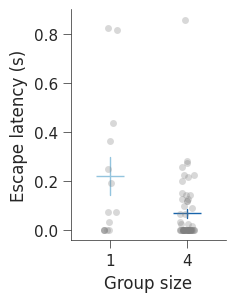


Escape probability:
Group 1: 14/15 escaped (93.3%)
Group 4: 58/60 escaped (96.7%)

Ns, means, and  sems for data:
1: (N=14) 0.219, 0.078
4: (N=58) 0.067, 0.018

Normality test (Shapiro-Wilk):
Group 1: W = 0.761, p = 1.6996206393e-03
Group 4: W = 0.537, p = 3.0032236489e-12
not all groups are normally distributed → use nonparametric test.

Mann-Whitney U: U = 540.000, p = 3.6901350484e-02


,1,4
0,0.074380,0.000000
1,0.000000,0.148760
2,0.000000,0.024793
3,0.000000,0.000000
4,0.247934,0.198347
5,0.826446,0.066116
6,0.818182,0.123967
7,0.190083,0.016529
8,0.438017,0.000000
9,0.000000,0.000000


In [ ]:
# classify post stim swim by threshold
subpanel = 'S2h'

group_sizes = [1,4]
escape_latency = {g:[] for g in group_sizes}
escape_window = [0,1]

dt_sec = 0.05  # sampling interval for delta heading
fps = 121      # frames per second (adjust as needed)
sliding_window = 5 # frames to smooth data

# stimulus-relative windows (in sec)
window_times = {'baseline': (-30, 0)}

# prepare pooling structure
group_sizes = [1, 4]  # example
pooled_speeds = {g: {w: [] for w in window_times} for g in group_sizes}

for exp in experiments:
  load_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp]
  if fish_num not in group_sizes: continue

  # load heading data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  scale = data['scale']
  f_speed = data['f_speed']*scale  # shape: fish_num x frame_num

  # load stimulus frame
  data = np.load(load_path + 'lev0_tap.npz', allow_pickle=True)
  tap_frame = data['tap_frames'][0]

  # use sliding window max
  speed_win = np.array([[np.max(speed[i:i + sliding_window])
            for i in range(len(speed) - sliding_window + 1)] for speed in f_speed])

  i0 = tap_frame + int(escape_window[0] * fps)
  i1 = tap_frame + int(escape_window[1] * fps)

  for f in range(fish_num):
    post_speed = speed_win[f][i0:i1]
    threshold = baseline_gaussian_df[fish_num]['escape_threshold']
    above = np.where(post_speed > threshold)[0]
    if len(above) > 0:
        first_idx = above[0]
        latency = first_idx / fps
        escape_latency[fish_num].append(latency)
    else:
        escape_latency[fish_num].append(np.nan)

# escape_latency
group_values = escape_latency
hex_colors = ['#93c4de', '#1764ab']

# plot
plt.figure(figsize=[2,3])
sns.stripplot(data=group_values,color='gray',alpha=0.3,size=5)
sns.pointplot(data=group_values,palette=hex_colors,linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);
plt.xlabel('Group size'); plt.ylabel(f'Escape latency (s)')
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight');
plt.show()

# stats
group_sizes = list(group_values.keys())
groups = group_values.keys()
summary_data = group_values.values()

print("\nEscape probability:")
for g, vals in group_values.items():
    vals = np.array(vals)
    n_total = len(vals)
    n_escape = np.sum(~np.isnan(vals))
    print(f"Group {g}: {n_escape}/{n_total} escaped ({100*n_escape/n_total:.1f}%)")

## -- 0. remove NaN values for subsequent stats -- ##
summary_data = {i: [] for i in groups}
for i, data in group_values.items():
  tmp = np.array(group_values[i])
  summary_data[i] = tmp[~np.isnan(tmp)]
summary_data = list(summary_data.values())
group_values = {g:data for g, data in zip(groups,summary_data)}

print("\nNs, means, and  sems for data:")
for id, s in enumerate(summary_data):
  print(f'{group_sizes[id]}: (N={len(s)}) {np.nanmean(s):.3f}, {scipy.stats.sem(s,nan_policy='omit'):.3f}')

## -- 1. Test for normality in each group -- ##
print("\nNormality test (Shapiro-Wilk):")
normality_results = {}
for group, data in zip(groups, summary_data):
  stat, p = stats.shapiro(data)
  normality_results[group] = {'W': stat, 'p': p}
for g, res in normality_results.items():
  print(f"Group {g}: W = {res['W']:.3f}, p = {res['p']:.10e}")

is_normal = all(res['p'] > 0.05 for res in normality_results.values());
if is_normal: print("all groups are normally distributed \u2192 use parametric test.")
else: print("not all groups are normally distributed \u2192 use nonparametric test.")

## -- 2. Group comparisons (& post hoc test) -- ##
unique_groups = len(groups);
if unique_groups == 2:
  groups = list(groups); summary_data = group_values
  #  Two groups: t-test or Mann-Whitney
  if is_normal:
    stat, p = stats.ttest_ind(summary_data[groups[0]], summary_data[groups[1]])
    print(f"\nT-test: t = {stat:.3f}, p = {p:.10e}")
  else:
    stat, p = stats.mannwhitneyu(summary_data[groups[0]], summary_data[groups[1]])
    print(f"\nMann-Whitney U: U = {stat:.3f}, p = {p:.10e}")

elif unique_groups > 2:
  if is_normal: # One-way ANOVA
    summary_data = list(group_values.values())
    groups = list(group_values.keys())
    df = pd.DataFrame({'data': np.concatenate(summary_data), 'group': np.repeat(groups, [len(d) for d in summary_data])})
    # Define the formula
    formula = 'data ~ group'
    # Fit the model
    model = smf.ols(formula, data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print("\nOne-way ANOVA:\n", anova_table)
    if anova_table['PR(>F)'][0] < 0.05:
      flat_data = [val for sublist in summary_data for val in sublist]
      groups = [group_names[i] for i, sublist in enumerate(summary_data) for _ in sublist]
      tukey = pairwise_tukeyhsd(endog=flat_data, groups=groups, alpha=0.05)
      print("\nTukey's HSD post hoc test:\n", tukey.summary())
      for res in tukey._results_table.data[1:]:
        g1, g2, p = res[0], res[1], res[4]

  else: # Kruskal-Wallis test
    stat, p = stats.kruskal(*summary_data)
    print(f"\nKruskal-Wallis H-test: H = {stat:.3f}, p = {p:.10e}")
    if p < 0.05:
      # Dunn's post hoc test with Bonferroni correction
      data_for_dunn = list(summary_data); group_for_dunn = list(groups)
      dunn = scikit.posthoc_dunn(data_for_dunn, p_adjust='bonferroni')
      print("\nDunn's post hoc test with bonferroni correction: ",group_for_dunn)
      print(dunn)

# save source data into csv
series_dict = {}
for key, values in group_values.items(): series_dict[key] = pd.Series(values)

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+f'.csv', index=False)

# S2i - iid% time series

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S2i


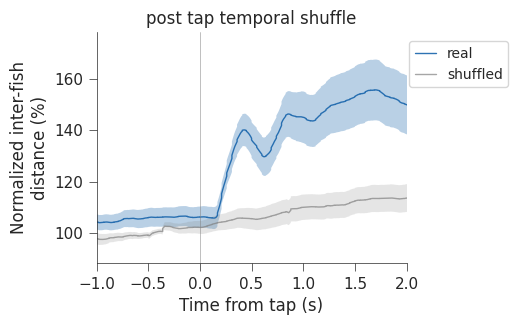

N = [90]
N shuffled = [90]


,real_1,real_2,real_3,real_4,real_5,real_6,real_7,real_8,real_9,real_10,...,shuffled_81,shuffled_82,shuffled_83,shuffled_84,shuffled_85,shuffled_86,shuffled_87,shuffled_88,shuffled_89,shuffled_90
0,131.393645,103.852286,40.611491,109.242261,172.030020,129.948626,94.620253,107.234407,84.451878,120.592369,...,82.114087,113.526930,90.484529,107.722826,35.023434,104.653997,101.890194,104.781619,54.451789,60.003256
1,132.332974,104.105407,40.849632,111.265932,173.493105,130.242705,95.049776,107.367140,85.172948,120.841037,...,82.240359,113.020711,90.541923,105.956271,34.291698,102.779748,101.622469,105.548946,54.994631,60.745793
2,132.842964,104.152860,41.450170,112.696779,173.757539,129.898992,95.127323,107.364960,85.352047,121.100775,...,82.377501,113.386312,90.652851,105.103569,34.310891,101.256237,101.376708,106.282371,56.223111,61.025034
3,133.366265,104.480234,41.658754,113.939509,174.531081,130.282735,95.134035,107.363943,85.480560,121.150881,...,82.858788,113.551853,90.678690,103.200934,34.316674,99.096756,101.136440,107.248784,58.055758,61.562136
4,133.878673,105.257591,41.880298,115.484204,175.312798,131.296581,95.171871,107.375114,84.926649,121.172972,...,83.486636,113.361220,90.987960,102.815544,34.318840,97.017375,100.969883,108.022391,60.068737,62.142006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,56.721915,120.437420,383.612465,237.517501,201.942104,16.935878,114.014436,43.783871,207.304942,75.135526,...,133.735987,197.088780,177.343380,160.354396,153.458642,159.766098,183.064071,120.353231,51.899622,206.709875
359,57.696485,120.872400,389.283557,239.464254,205.478713,16.840826,113.985973,43.333392,206.559763,75.179058,...,132.798110,196.020820,177.495272,159.419791,151.962031,162.148373,182.356193,120.216863,51.884841,206.626514
360,57.728554,121.738515,393.411140,240.065624,206.890260,16.267268,113.972612,43.145694,205.896455,74.991463,...,131.897381,195.134387,177.637020,158.852166,150.372809,163.324495,181.705652,120.318647,51.521812,206.677833
361,57.289556,122.617502,396.386432,239.749257,206.842183,15.952671,113.970896,43.092437,205.243558,74.444623,...,131.072034,194.268082,178.000121,158.720213,148.834227,165.127927,181.067410,120.563918,51.192188,206.391488


In [ ]:
subpanel = 'S2i'

group_sizes = [4]
group_values = {n: [] for n in group_sizes}
group_values_shuffled = {n: [] for n in group_sizes}  # Add shuffled data storage
hex_colors = ['#1764ab']

for exp in experiments[::]:
    load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
    fish_num = metadata.fish_num[exp];
    if fish_num not in group_sizes: continue

    # load data
    data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
    scale, fps, frame_num =  data['scale'], data['fps'], data['frame_num']
    f_bodylength_px = data['f_bodylength_px']

    data = np.load(load_path + 'lev0_group_basics.npz', allow_pickle=True)
    f_IID = data['f_IID']
    f_IID_bd = f_IID/np.mean(f_bodylength_px)

    data = np.load(load_path + 'lev0_tap.npz', allow_pickle=True)
    tap = data['tap_frames'][0]

    # closest distance - real data
    baseline = [np.mean(dist[tap-int(5*fps):tap]) for dist in f_IID_bd]
    tmp = [(dist/base) for dist, base in zip(f_IID_bd,baseline)]

    # Create shuffled version
    tmp_shuffled = []
    for dist in f_IID_bd:
      # Roll each timeseries by a random amount
      random_shift = np.random.randint(0, len(dist))
      shuffled_dist = np.roll(dist, random_shift)

      # Calculate baseline after shuffling
      baseline_shuffled = np.mean(shuffled_dist[tap-int(1*fps):tap])
      tmp_shuffled.append(shuffled_dist/baseline_shuffled)

    # append real data
    pair_num = f_IID.shape[0]
    for f in range(pair_num):
      group_values[fish_num].append(tmp[f][tap-int(30*121):tap+int(30*121)]*100)
      group_values_shuffled[fish_num].append(tmp_shuffled[f][tap-int(30*121):tap+int(30*121)]*100)

# make time_sec relative to tap for plotting
pre = np.linspace(-30,0,30*121); post = np.linspace(0,30,30*121)
rel_time = np.concatenate((pre,post)); rel_sec = np.round(rel_time,2)

# PLOT # mean+sem
labels = ['real','shuffled']
plt.figure(figsize=[4,3])
for i, gs in enumerate(group_sizes):
  # Plot real data
  plt.plot(rel_sec,np.mean(group_values[gs],axis=0),linewidth=1,c=hex_colors[i],alpha=0.9,label='real')
  plt.fill_between(rel_sec, np.mean(group_values[gs],axis=0)-scipy.stats.sem(group_values[gs],axis=0), \
                    np.mean(group_values[gs],axis=0)+scipy.stats.sem(group_values[gs],axis=0),color=hex_colors[i],alpha=0.3,linewidth=0)

  # Plot shuffled data in grey
  plt.plot(rel_sec,np.mean(group_values_shuffled[gs],axis=0),linewidth=1,c='grey',alpha=0.7,label=f"shuffled")
  plt.fill_between(rel_sec, np.mean(group_values_shuffled[gs],axis=0)-scipy.stats.sem(group_values_shuffled[gs],axis=0), \
                    np.mean(group_values_shuffled[gs],axis=0)+scipy.stats.sem(group_values_shuffled[gs],axis=0),color='grey',alpha=0.2,linewidth=0)

plt.axvline(0,c='grey',linewidth=0.5, alpha=0.7)
plt.legend(bbox_to_anchor=(1,0.75),handlelength=1.5,markerscale=0.7,borderaxespad=0.2,fontsize=10)
plt.xlim(-1,2); # plt.ylim(0.75,1.9);
plt.xlabel('Time from tap (s)'); plt.title('post tap temporal shuffle');
plt.ylabel('Normalized inter-fish\ndistance (%)')
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight');
plt.show()

print(f"N = {[len(group_values[g]) for g in group_sizes]}")
print(f"N shuffled = {[len(group_values_shuffled[g]) for g in group_sizes]}")

# save source data into csv - for time series, save out the visible part
ST, ED = -30, 30; st, ed = -1, 2; fps = 121

series_dict = {}
for group, samples in group_values.items():
  for i, sample in enumerate(samples):
    col_name = f"real_{i+1}"
    series_dict[col_name] = pd.Series(sample[int((st-ST)*fps):int((ed-ST)*fps)])
for group, samples in group_values_shuffled.items():
  for i, sample in enumerate(samples):
    col_name = f"shuffled_{i+1}"
    series_dict[col_name] = pd.Series(sample[int((st-ST)*fps):int((ed-ST)*fps)])

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# S2j - iid% stats

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S2j


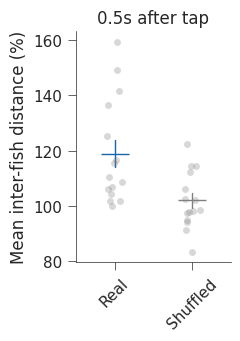

Ns, means, and sems for data:
Real: (N=15) 118.943, 4.911
Shuffled: (N=15) 102.015, 2.654

Normality test (Shapiro-Wilk):
Group Real: W = 0.857, p = 2.1706515683e-02
Group Shuffled: W = 0.962, p = 7.2699676622e-01
not all groups are normally distributed → use nonparametric test.

Mann-Whitney U: U = 180.000, p = 5.4521398569e-03


,real,shuffled
0,106.022552,114.433454
1,141.724288,94.881795
2,104.344837,102.578102
3,149.086342,98.408102
4,106.757670,106.293888
5,116.668663,122.337484
6,110.494132,94.368819
7,125.150983,98.029768
8,101.812678,97.316803
9,159.291966,114.286727


In [ ]:
subpanel = 'S2j'
window_of_interest = [0.5]

for woi in window_of_interest:

  group_values = {}; shuffled_values = {}
  hex_colors = ['#1764ab']

  for exp in experiments[::]:
      load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
      fish_num = metadata.fish_num[exp];
      if fish_num != 4: continue

      # Initialize dictionaries for this fish_num if not exists
      if fish_num not in group_values:
          group_values[fish_num] = []
          shuffled_values[fish_num] = []

      data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
      scale, fps, frame_num =  data['scale'], data['fps'], data['frame_num']
      f_bodylength_px = data['f_bodylength_px']

      data = np.load(load_path + 'lev0_group_basics.npz', allow_pickle=True)
      f_IID = data['f_IID']
      f_IID_bd = f_IID/np.mean(f_bodylength_px)

      data = np.load(load_path + 'lev0_tap.npz', allow_pickle=True)
      tap = data['tap_frames'][0]

      # closest distance - real data
      baseline = [np.mean(dist[tap-int(1*fps):tap]) for dist in f_IID_bd]
      tmp = [(dist/base) for dist, base in zip(f_IID_bd,baseline)]

      # Create shuffled version
      tmp_shuffled = []
      for dist in f_IID_bd:
        # Roll each timeseries by a random amount
        random_shift = np.random.randint(0, len(dist))
        shuffled_dist = np.roll(dist, random_shift)

        # Calculate baseline after shuffling
        baseline_shuffled = np.mean(shuffled_dist[tap-int(1*fps):tap])
        tmp_shuffled.append(shuffled_dist/baseline_shuffled)

      # get change btw pre and post tap
      window = int(fps*woi); dt = 1/fps;
      # delta = [np.trapezoid(t[tap:tap+window],dx=dt) for t in tmp] # auc
      delta = [np.mean(t[tap:tap+window]) for t in tmp] # mean
      delta_shuffled = [np.mean(t[tap:tap+window]) for t in tmp_shuffled] # mean for shuffled

      group_values[fish_num].append(np.mean(delta)*100)
      shuffled_values[fish_num].append(np.mean(delta_shuffled)*100)

  # Combine real and shuffled data for plotting
  plot_data = {'Real': group_values[4], 'Shuffled': shuffled_values[4]}

  # plot
  plt.figure(figsize=[2,3])
  sns.stripplot(data=plot_data, color='gray', alpha=0.3, size=5)
  sns.pointplot(data=plot_data, palette=['#1764ab', 'gray'], linestyle="none", marker="_",
                estimator='mean', errorbar='se', markersize=20, markeredgewidth=1, errwidth=1)
  plt.xticks(rotation=45); plt.ylabel('Mean inter-fish distance (%)'); # plt.ylim(0,350)
  sns.despine(); plt.title(f'{woi}s after tap')
  print(figure_path+subpanel)
  plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight')
  plt.show()

  # stats
  groups = ['Real', 'Shuffled']
  summary_data = [group_values[4], shuffled_values[4]]
  print("Ns, means, and sems for data:")
  for id, s in enumerate(summary_data):
    print(f'{groups[id]}: (N={len(s)}) {np.nanmean(s):.3f}, {scipy.stats.sem(s):.3f}')

  ## -- 1. Test for normality in each group -- ##
  print("\nNormality test (Shapiro-Wilk):")
  normality_results = {}
  for group, data in zip(groups, summary_data):
      stat, p = stats.shapiro(data)
      normality_results[group] = {'W': stat, 'p': p}
  for g, res in normality_results.items():
      print(f"Group {g}: W = {res['W']:.3f}, p = {res['p']:.10e}")

  is_normal = all(res['p'] > 0.05 for res in normality_results.values())
  if is_normal:
      print("all groups are normally distributed → use parametric test.")
  else:
      print("not all groups are normally distributed → use nonparametric test.")

  ## -- 2. Group comparisons (& post hoc test) -- ##
  unique_groups = len(groups)

  # Two groups: t-test or Mann-Whitney
  if is_normal:
      stat, p = stats.ttest_ind(summary_data[0], summary_data[1])
      print(f"\nT-test: t = {stat:.3f}, p = {p:.10e}")
  else:
      stat, p = stats.mannwhitneyu(summary_data[0], summary_data[1])
      print(f"\nMann-Whitney U: U = {stat:.3f}, p = {p:.10e}")

  # save source data into csv
  series_dict = {}
  series_dict['real'] = pd.Series(group_values[4])
  series_dict['shuffled'] = pd.Series(shuffled_values[4])

  df = pd.DataFrame(series_dict)
  display(df)
  df.to_csv(csv_path+subpanel+f'.csv', index=False)

# S2k - iid (bd) time series

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S2k


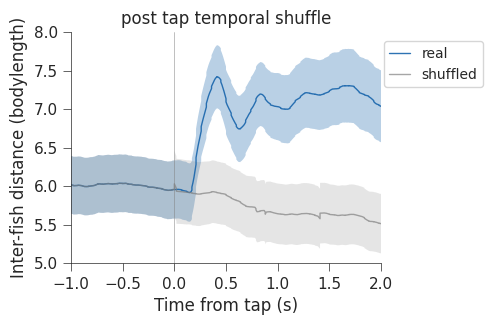

N = [15]
N shuffled = [15]


,real_1,real_2,real_3,real_4,real_5,real_6,real_7,real_8,real_9,real_10,...,shuffled_81,shuffled_82,shuffled_83,shuffled_84,shuffled_85,shuffled_86,shuffled_87,shuffled_88,shuffled_89,shuffled_90
0,4.947161,5.163973,0.602515,2.748075,4.690694,4.652874,4.897061,9.404073,1.325435,5.164521,...,3.427134,6.220745,9.124518,3.924406,15.501476,3.469527,13.560119,12.055213,2.137581,10.094395
1,4.982529,5.176560,0.606048,2.798982,4.730587,4.663403,4.919291,9.415713,1.336752,5.175171,...,3.401290,6.248025,9.153503,3.940219,15.460715,3.480214,13.543135,12.002765,2.126660,10.065973
2,5.001730,5.178919,0.614957,2.834976,4.737798,4.651097,4.923305,9.415522,1.339563,5.186294,...,3.395528,6.262604,9.171822,3.951468,15.420306,3.480661,13.525823,11.961996,2.116660,10.047939
3,5.021433,5.195198,0.618052,2.866238,4.758890,4.664837,4.923652,9.415432,1.341580,5.188440,...,3.378063,6.269396,9.206266,3.974840,15.401120,3.520742,13.510768,11.903839,2.114771,9.993068
4,5.040726,5.233851,0.621339,2.905096,4.780204,4.701138,4.925610,9.416412,1.332886,5.189386,...,3.357715,6.277435,9.238245,4.003451,15.369679,3.564024,13.484126,11.830684,2.111379,9.923592
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,2.135662,5.988656,5.691299,5.974940,5.506298,0.606397,5.900805,3.839688,3.253559,3.217774,...,1.572345,7.497138,5.616467,2.260498,9.735037,2.264061,2.607101,1.856816,10.189369,4.091511
359,2.172356,6.010285,5.775436,6.023912,5.602730,0.602994,5.899332,3.800183,3.241864,3.219638,...,1.574211,7.422966,5.634901,2.246915,9.644901,2.287922,2.609119,1.849282,10.221802,4.057978
360,2.173564,6.053352,5.836673,6.039040,5.641218,0.582457,5.898641,3.783722,3.231454,3.211604,...,1.570159,7.363922,5.648859,2.234033,9.576860,2.288890,2.597043,1.885755,10.259503,4.024871
361,2.157035,6.097059,5.880815,6.031081,5.639907,0.571193,5.898552,3.779052,3.221207,3.188185,...,1.569887,7.299420,5.668245,2.222385,9.563661,2.300017,2.581948,1.908569,10.280606,3.979316


In [ ]:
subpanel = 'S2k'
group_sizes = [4]
group_values = {n: [] for n in group_sizes}
group_values_shuffled = {n: [] for n in group_sizes}  # Add shuffled data storage
hex_colors = ['#1764ab']

for exp in experiments[::]:
    load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
    fish_num = metadata.fish_num[exp];
    if fish_num not in group_sizes: continue

    # load data
    data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
    scale, fps, frame_num =  data['scale'], data['fps'], data['frame_num']
    f_bodylength_mm = data['f_bodylength_mm']

    data = np.load(load_path + 'lev0_group_basics.npz', allow_pickle=True)
    f_IID = data['f_IID'] # in mm
    f_IID_bd = f_IID/np.mean(f_bodylength_mm)

    data = np.load(load_path + 'lev0_tap.npz', allow_pickle=True)
    tap = data['tap_frames'][0]

    # Create shuffled version
    tmp_shuffled = []

    for dist in f_IID_bd:
      # shuffle post tap only
      random_shift = np.random.randint(0, len(dist[:tap],))
      shuffled_post_dist = np.roll(dist[tap:], random_shift)
      shuffled_dist = np.concatenate((dist[:tap], shuffled_post_dist))

      tmp_shuffled.append(shuffled_dist)

    # get change btw pre and post tap
    window = int(fps*escp_window); dt = 1/fps;
    delta = [np.mean(t[tap:tap+window]) for t in f_IID_bd] # mean

    # append real data
    pair_num = f_IID.shape[0]
    for f in range(pair_num):
      group_values[fish_num].append(f_IID_bd[f][tap-int(30*121):tap+int(30*121)])
      group_values_shuffled[fish_num].append(tmp_shuffled[f][tap-int(30*121):tap+int(30*121)])

# make time_sec relative to tap for plotting
pre = np.linspace(-30,0,30*121); post = np.linspace(0,30,30*121)
rel_time = np.concatenate((pre,post)); rel_sec = np.round(rel_time,2)

# PLOT # mean+sem
labels = ['real','shuffled']
plt.figure(figsize=[4,3])
for i, gs in enumerate(group_sizes):
  # Plot real data
  plt.plot(rel_sec,np.mean(group_values[gs],axis=0),linewidth=1,c=hex_colors[i],alpha=0.9,label='real')
  plt.fill_between(rel_sec, np.mean(group_values[gs],axis=0)-scipy.stats.sem(group_values[gs],axis=0), \
                    np.mean(group_values[gs],axis=0)+scipy.stats.sem(group_values[gs],axis=0),color=hex_colors[i],alpha=0.3,linewidth=0)

  # Plot shuffled data in grey
  plt.plot(rel_sec,np.mean(group_values_shuffled[gs],axis=0),linewidth=1,c='grey',alpha=0.7,label=f"shuffled")
  plt.fill_between(rel_sec, np.mean(group_values_shuffled[gs],axis=0)-scipy.stats.sem(group_values_shuffled[gs],axis=0), \
                    np.mean(group_values_shuffled[gs],axis=0)+scipy.stats.sem(group_values_shuffled[gs],axis=0),color='grey',alpha=0.2,linewidth=0)

plt.axvline(0,c='grey',linewidth=0.5, alpha=0.7)
plt.legend(bbox_to_anchor=(1,0.75),handlelength=1.5,markerscale=0.7,borderaxespad=0.2,fontsize=10)
plt.xlim(-1,2); plt.ylim(5,8); plt.title('post tap temporal shuffle')
plt.xlabel('Time from tap (s)'); plt.ylabel('Inter-fish distance (bodylength)')
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight');
plt.show()

print(f"N = {[int(len(group_values[g])/math.comb(4,2)) for g in group_sizes]}")
print(f"N shuffled = {[int(len(group_values_shuffled[g])/math.comb(4,2)) for g in group_sizes]}")

# save source data into csv - for time series, save out the visible part
ST, ED = -30, 30; st, ed = -1, 2; fps = 121

series_dict = {}
for group, samples in group_values.items():
  for i, sample in enumerate(samples):
    col_name = f"real_{i+1}"
    series_dict[col_name] = pd.Series(sample[int((st-ST)*fps):int((ed-ST)*fps)])
for group, samples in group_values_shuffled.items():
  for i, sample in enumerate(samples):
    col_name = f"shuffled_{i+1}"
    series_dict[col_name] = pd.Series(sample[int((st-ST)*fps):int((ed-ST)*fps)])

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# S2l - iid% long time series

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S2l


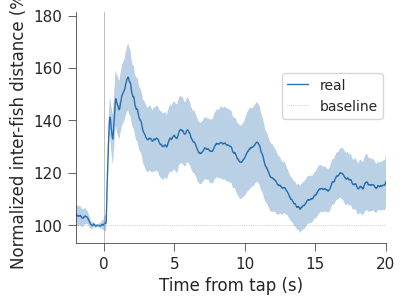

N = [15]
N shuffled = [15]


,real_1,real_2,real_3,real_4,real_5,real_6,real_7,real_8,real_9,real_10,...,shuffled_81,shuffled_82,shuffled_83,shuffled_84,shuffled_85,shuffled_86,shuffled_87,shuffled_88,shuffled_89,shuffled_90
0,56.927475,79.166156,97.570935,36.294479,46.146853,75.867498,103.139913,94.263979,150.547335,66.634886,...,1514.189651,1564.270962,266.939815,1301.406906,1776.528447,213.206881,1514.189651,1564.270962,266.939815,1301.406906
1,56.732648,79.187068,96.666597,36.366195,46.107589,75.908301,103.156360,94.311007,148.938709,66.874328,...,1513.326392,1565.895917,267.971768,1301.839295,1776.916450,211.825147,1513.326392,1565.895917,267.971768,1301.839295
2,56.754910,79.422138,97.105803,36.474471,46.087988,75.995290,103.152610,94.408342,147.190142,67.135049,...,1515.631352,1567.579350,268.984956,1302.345385,1780.494867,213.483990,1515.631352,1567.579350,268.984956,1302.345385
3,57.344513,79.672303,96.960851,36.007353,46.760293,76.295902,103.160790,94.381461,145.347653,67.192110,...,1518.049565,1570.501266,270.266161,1304.100395,1784.114881,214.092491,1518.049565,1570.501266,270.266161,1304.100395
4,57.935347,80.087050,97.510819,35.941126,47.344437,76.615093,103.121659,94.201139,143.491570,67.050765,...,1518.299778,1573.352913,271.606693,1305.724607,1785.629842,212.673077,1518.299778,1573.352913,271.606693,1305.724607
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2657,38.902608,90.446373,182.067031,179.683892,13.594092,139.565718,184.705476,132.838659,270.229616,78.259212,...,684.532902,677.680833,319.262514,723.495042,327.182639,129.515475,684.532902,677.680833,319.262514,723.495042
2658,38.747997,90.566242,181.646914,179.492546,13.777049,139.251929,184.202265,132.857737,273.289724,78.502613,...,686.148098,679.688260,320.921607,719.325064,326.577206,128.270401,686.148098,679.688260,320.921607,719.325064
2659,39.290548,90.179779,182.043484,179.631810,14.446355,138.599218,183.395913,132.889361,276.237830,79.198444,...,689.536732,683.260074,322.835550,712.010309,326.782719,127.075383,689.536732,683.260074,322.835550,712.010309
2660,39.657672,89.747282,182.440586,179.559002,15.031073,137.913778,182.567112,132.936528,279.248095,79.934443,...,692.818998,689.275302,324.712886,706.865363,326.922743,126.032754,692.818998,689.275302,324.712886,706.865363


In [ ]:
subpanel = 'S2l'

group_sizes = [4]
group_values = {n: [] for n in group_sizes}
group_values_shuffled = {n: [] for n in group_sizes}  # Add shuffled data storage
hex_colors = ['#1764ab']
bin_values = {n: [] for n in np.arange(-30,30)}

for exp in experiments[::]:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp];
  if fish_num not in group_sizes: continue

  # load data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  scale, fps, frame_num =  data['scale'], data['fps'], data['frame_num']
  f_bodylength_mm = data['f_bodylength_mm']

  data = np.load(load_path + 'lev0_group_basics.npz', allow_pickle=True)
  f_IID = data['f_IID']
  f_IID_bd = f_IID/np.mean(f_bodylength_mm)

  data = np.load(load_path + 'lev0_tap.npz', allow_pickle=True)
  tap = data['tap_frames'][0]

  # closest distance - real data normalized
  baseline = [np.mean(dist[tap-int(1*fps):tap]) for dist in f_IID_bd]
  tmp = [(dist/base) for dist, base in zip(f_IID_bd,baseline)]

  # take raw data baseline for recovery calculation later
  baseline_raw = f_IID_bd[tap-int(1*fps):tap]   # e.g. 3 s baseline
  baseline_mean_raw = np.mean(baseline_raw)
  baseline_sd_raw   = np.std(baseline_raw)

  # append real data
  pair_num = f_IID.shape[0]
  for f in range(pair_num):
    group_values[fish_num].append(tmp[f][tap-int(30*121):tap+int(30*121)]*100)
    group_values_shuffled[fish_num].append(tmp_shuffled[f][tap-int(30*121):tap+int(30*121)]*100)

# make time_sec relative to tap for plotting
pre = np.linspace(-30,0,30*121); post = np.linspace(0,30,30*121)
rel_time = np.concatenate((pre,post)); rel_sec = np.round(rel_time,2)

# PLOT # mean+sem
labels = ['real'] #,'shuffled']
plt.figure(figsize=[4,3])
for i, gs in enumerate(group_sizes):
  # Plot real data
  plt.plot(rel_sec,np.mean(group_values[gs],axis=0),linewidth=1,c=hex_colors[i],alpha=0.9,label='real')
  plt.fill_between(rel_sec, np.mean(group_values[gs],axis=0)-scipy.stats.sem(group_values[gs],axis=0), \
                    np.mean(group_values[gs],axis=0)+scipy.stats.sem(group_values[gs],axis=0),color=hex_colors[i],alpha=0.3,linewidth=0)

  # Plot baseline (1-sec pre tap)
  tmp = np.array([t[29*121:30*121] for t in group_values[gs]]) # take 5s before tap
  baseline_mean = np.nanmean(np.nanmean(tmp))
  plt.axhline(baseline_mean,c='darkgray',linestyle=':',linewidth=0.5, label='baseline')


plt.axvline(0,c='grey',linewidth=0.5, alpha=0.7)
plt.legend(bbox_to_anchor=(1,0.75),handlelength=1.5,markerscale=0.7,borderaxespad=0.2,fontsize=10)
plt.xlim(-2,20);
plt.xlabel('Time from tap (s)'); plt.ylabel('Normalized inter-fish distance (%)')
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight');
plt.show()

print(f"N = {[int(len(group_values[g])/math.comb(4,2)) for g in group_sizes]}")
print(f"N shuffled = {[int(len(group_values_shuffled[g])/math.comb(4,2)) for g in group_sizes]}")

# save source data into csv - for time series, save out the visible part
ST, ED = -30, 30; st, ed = -2, 20; fps = 121

series_dict = {}
for group, samples in group_values.items():
  for i, sample in enumerate(samples):
    col_name = f"real_{i+1}"
    series_dict[col_name] = pd.Series(sample[int((st-ST)*fps):int((ed-ST)*fps)])
for group, samples in group_values_shuffled.items():
  for i, sample in enumerate(samples):
    col_name = f"shuffled_{i+1}"
    series_dict[col_name] = pd.Series(sample[int((st-ST)*fps):int((ed-ST)*fps)])

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# S2m - iid% traj shuffle time series

In [ ]:
def neighbor_stats(f_x, f_y, f_heading, scale):
  fish_num, frame_num = f_x.shape
  if f_y.shape[0] != fish_num: print('data compromised')

  # initialize arrays and lists
  ff_dist = np.zeros((fish_num,fish_num-1,frame_num))
  ff_align = np.zeros((fish_num,fish_num-1,frame_num))
  f_IID = []; f_IIA = [] # number of dyads x framenum
  f_closest_id = np.zeros((fish_num,frame_num))
  f_closest_dist = np.zeros((fish_num,frame_num))
  f_closest_align = np.zeros((fish_num,frame_num))

  # loop through ind fish
  for f0 in range(fish_num):
    nb_count = 0
    for f1 in range(fish_num):
      if f1 != f0:
        nb_count += 1
        dist = np.abs(np.sqrt( (f_x[f0]-f_x[f1])**2 + (f_y[f0]-f_y[f1])**2 ) )*scale
        align = ((( f_heading[f0]-f_heading[f1] ) + 180) % 360 - 180)
        ff_dist[f0][nb_count-1] = dist
        ff_align[f0][nb_count-1] = align
      if f0 < f1:
        f_IID.append(dist)
        f_IIA.append(align)
  f_IID = np.array(f_IID)
  f_IIA = np.array(f_IIA)

  # find the stats with the closest neighbor for each fish
  for f0 in range(fish_num):
    closest_dist = np.array(np.min(ff_dist[f0],axis=0)) # find the smallest dist in each frame
    f_closest_id[f0] = np.argmin(ff_dist[f0] == closest_dist, axis=0) # identify which fish it is
    index = f_closest_id[f0].astype(int)
    f_closest_dist[f0] = closest_dist # find their distance
    f_closest_align[f0] = ff_align[f0][index,np.arange(len(index))] # find their alignment

  return f_IID, f_IIA, f_closest_dist, f_closest_align

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S2m


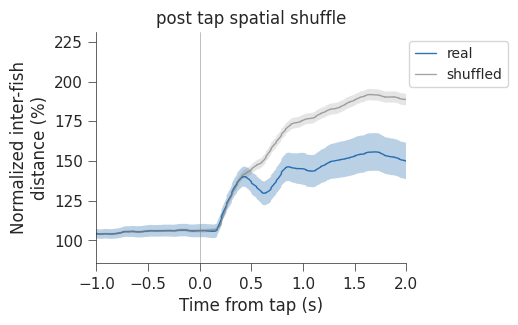

N = [15]
N shuffled = [15]


,real_1,real_2,real_3,real_4,real_5,real_6,real_7,real_8,real_9,real_10,...,shuffled_351,shuffled_352,shuffled_353,shuffled_354,shuffled_355,shuffled_356,shuffled_357,shuffled_358,shuffled_359,shuffled_360
0,131.393645,103.852286,40.611491,109.242261,172.030020,129.948626,94.620253,107.234407,84.451878,120.592369,...,102.095569,102.095569,102.095569,102.095569,102.095569,102.095569,102.095569,102.095569,102.095569,102.095569
1,132.332974,104.105407,40.849632,111.265932,173.493105,130.242705,95.049776,107.367140,85.172948,120.841037,...,101.887037,101.887037,101.887037,101.887037,101.887037,101.887037,101.887037,101.887037,101.887037,101.887037
2,132.842964,104.152860,41.450170,112.696779,173.757539,129.898992,95.127323,107.364960,85.352047,121.100775,...,101.663145,101.663145,101.663145,101.663145,101.663145,101.663145,101.663145,101.663145,101.663145,101.663145
3,133.366265,104.480234,41.658754,113.939509,174.531081,130.282735,95.134035,107.363943,85.480560,121.150881,...,101.655042,101.655042,101.655042,101.655042,101.655042,101.655042,101.655042,101.655042,101.655042,101.655042
4,133.878673,105.257591,41.880298,115.484204,175.312798,131.296581,95.171871,107.375114,84.926649,121.172972,...,101.580182,101.580182,101.580182,101.580182,101.580182,101.580182,101.580182,101.580182,101.580182,101.580182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,56.721915,120.437420,383.612465,237.517501,201.942104,16.935878,114.014436,43.783871,207.304942,75.135526,...,188.239647,258.327225,229.615913,165.280827,216.581691,200.806912,201.031315,189.993673,216.581691,202.314068
359,57.696485,120.872400,389.283557,239.464254,205.478713,16.840826,113.985973,43.333392,206.559763,75.179058,...,188.406054,258.391755,229.743574,165.521832,216.980277,200.962400,201.212580,190.447035,216.980277,202.654497
360,57.728554,121.738515,393.411140,240.065624,206.890260,16.267268,113.972612,43.145694,205.896455,74.991463,...,188.428705,258.525439,229.898661,165.776445,217.245961,200.992538,201.265646,190.849204,217.245961,202.839029
361,57.289556,122.617502,396.386432,239.749257,206.842183,15.952671,113.970896,43.092437,205.243558,74.444623,...,188.359745,258.698287,230.045181,166.135586,217.354847,200.922802,201.218310,191.178712,217.354847,202.915787


In [ ]:
subpanel = 'S2m'

group_sizes = [4]
group_values = {n: [] for n in group_sizes}
group_values_shuffled = {n: [] for n in group_sizes}  # Add shuffled data storage
hex_colors = ['#1764ab']

for exp in experiments[::]:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp];
  if fish_num not in group_sizes: continue

  # load data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  scale, fps, frame_num =  data['scale'], data['fps'], data['frame_num']
  f_bodylength_mm = data['f_bodylength_mm']
  f_x, f_y, f_heading = data['f_x'], data['f_y'], data['f_heading']

  data = np.load(load_path + 'lev0_tap.npz', allow_pickle=True)
  tap = data['tap_frames'][0]

  # Real data
  f_IID, f_IIA, f_closest_dist, f_closest_align = neighbor_stats(f_x, f_y, f_heading, scale)
  f_IID_bd = f_IID/np.mean(f_bodylength_mm); # f_IID_mm = f_IID*scale
  f_closest_dist_bd = f_closest_dist/np.mean(f_bodylength_mm); # f_closest_dist_mm = f_closest_dist*scale

  # baseline = [np.mean(dist[tap-int(5*fps):tap]) for dist in f_IID]
  # baseline_bd = [np.mean(dist[tap-int(5*fps):tap]) for dist in f_IID_bd]
  baseline = [np.mean(dist[tap-int(5*fps):tap]) for dist in f_IID]
  normed_IID = [(dist/base) for dist, base in zip(f_IID,baseline)]

  # Create shuffled data
  mean_normed_IID_shuffled = []; n_iter = math.perm(fish_num)

  # Precompute escape displacements
  dx = f_x[:, tap:] - f_x[:, tap][:, None]
  dy = f_y[:, tap:] - f_y[:, tap][:, None]

  for it in range(n_iter):
    perm = np.random.permutation(fish_num)

    # Reassign trajectories to starting positions
    shuffled_x_post = f_x[:, tap][:, None] + dx[perm]
    shuffled_y_post = f_y[:, tap][:, None] + dy[perm]

    hybrid_x = np.hstack((f_x[:, :tap], shuffled_x_post))
    hybrid_y = np.hstack((f_y[:, :tap], shuffled_y_post))

    shuffled_IID, _, _, _ = neighbor_stats(hybrid_x, hybrid_y, f_heading, scale)

    baseline_shuffled = [np.mean(dist[tap-int(5*fps):tap]) for dist in shuffled_IID]
    normed_IID_shuffled = [dist / base for dist, base in zip(shuffled_IID, baseline_shuffled)]

    mean_normed_IID_shuffled.append(np.mean(normed_IID_shuffled, axis=0))

  mean_normed_IID_shuffled = np.array(mean_normed_IID_shuffled)

  # append data
  for f in range(f_IID.shape[0]):
    group_values[fish_num].append(normed_IID[f][tap-int(30*121):tap+int(30*121)]*100)
  for f in range(mean_normed_IID_shuffled.shape[0]):
    group_values_shuffled[fish_num].append(mean_normed_IID_shuffled[f][tap-int(30*121):tap+int(30*121)]*100)

# make time_sec relative to tap for plotting
pre = np.linspace(-30,0,30*121); post = np.linspace(0,30,30*121)
rel_time = np.concatenate((pre,post)); rel_sec = np.round(rel_time,2)

# PLOT # mean+sem
labels = ['real','shuffled']
plt.figure(figsize=[4,3])
for i, gs in enumerate(group_sizes):
  # Plot real data
  plt.plot(rel_sec,np.mean(group_values[gs],axis=0),linewidth=1,c=hex_colors[i],alpha=0.9,label='real')
  plt.fill_between(rel_sec, np.mean(group_values[gs],axis=0)-scipy.stats.sem(group_values[gs],axis=0), \
                    np.mean(group_values[gs],axis=0)+scipy.stats.sem(group_values[gs],axis=0),color=hex_colors[i],alpha=0.3,linewidth=0)

  # Plot shuffled data in grey
  plt.plot(rel_sec,np.mean(group_values_shuffled[gs],axis=0),linewidth=1,c='grey',alpha=0.7,label=f"shuffled")
  plt.fill_between(rel_sec, np.mean(group_values_shuffled[gs],axis=0)-scipy.stats.sem(group_values_shuffled[gs],axis=0), \
                    np.mean(group_values_shuffled[gs],axis=0)+scipy.stats.sem(group_values_shuffled[gs],axis=0),color='grey',alpha=0.2,linewidth=0)

plt.axvline(0,c='grey',linewidth=0.5, alpha=0.7)
plt.legend(bbox_to_anchor=(1,0.75),handlelength=1.5,markerscale=0.7,borderaxespad=0.2,fontsize=10)
plt.xlim(-1,2); plt.title('post tap spatial shuffle')
plt.xlabel('Time from tap (s)'); plt.ylabel('Normalized inter-fish\ndistance (%)')
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight');
plt.show()

print(f"N = {[int(len(group_values[g])/math.comb(4,2)) for g in group_sizes]}")
print(f"N shuffled = {[int(len(group_values_shuffled[g])/math.perm(g)) for g in group_sizes]}")

# save source data into csv - for time series, save out the visible part
ST, ED = -30, 30; st, ed = -1, 2; fps = 121

series_dict = {}
for group, samples in group_values.items():
  for i, sample in enumerate(samples):
    col_name = f"real_{i+1}"
    series_dict[col_name] = pd.Series(sample[(st-ST)*fps:(ed-ST)*fps])
for group, samples in group_values_shuffled.items():
  for i, sample in enumerate(samples):
    col_name = f"shuffled_{i+1}"
    series_dict[col_name] = pd.Series(sample[(st-ST)*fps:(ed-ST)*fps])

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# S2n+o (250ms)

In [13]:
group_sizes = [4]; group_values = {n: [] for n in group_sizes}
hex_colors = ['#1764ab']

dt_sec = 0.05  # sampling interval for delta heading
fps = 121      # frames per second (adjust as needed)

# stimulus-relative windows (in sec)
window_times = {f'{i:.2f}s':(i,i+0.25) for i in np.arange(-1,1.25,0.25)}

# prepare pooling structure
pooled_dtheta = {g: {w: [] for w in window_times} for g in group_sizes}

for exp in experiments:
  load_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp]
  if fish_num not in group_sizes: continue

  # load heading data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  f_heading = data['f_heading']  # shape: fish_num x frame_num

  # load stimulus frame
  data = np.load(load_path + 'lev0_tap.npz', allow_pickle=True)
  tap_frame = data['tap_frames'][0]

  # convert delta_t to frames
  dt = int(np.round(dt_sec * fps))
  # per-experiment metrics container
  metrics_exp = {w: {'iqr': [], 'p90': [], 'exp': exp} for w in window_times}

  # loop over windows
  for w_name, (t_start, t_end) in window_times.items():
    # compute start and stop frame indices relative to tap
    i0 = tap_frame + int(t_start * fps)
    i1 = tap_frame + int(t_end * fps)

    # collect |Δθ| for all fish in this experiment
    for f in range(fish_num):
      theta = f_heading[f, i0:i1]
      if len(theta) <= dt: continue
      # # wrapped delta heading in degrees
      dtheta = (theta[dt:] - theta[:-dt] + 180) % 360 - 180
      # abs_dtheta = np.abs(dtheta)
      pooled_dtheta[fish_num][w_name].append(dtheta)

    if not pooled_dtheta[fish_num][w_name]: continue
    all_dtheta = np.concatenate(pooled_dtheta[fish_num][w_name]);
    all_abs_dtheta = np.concatenate(np.abs(pooled_dtheta[fish_num][w_name]))

# after looping over all experiments, concatenate samples across experiments/fish
for g in pooled_dtheta:
  for w_name, _ in window_times.items():
    if pooled_dtheta[g][w_name]:  # avoid empty lists
      pooled_dtheta[g][w_name] = np.concatenate(pooled_dtheta[g][w_name])
    else:
      pooled_dtheta[g][w_name] = np.array([])

# map window index to a continuous scale
window_list = list(window_times.keys())
n_w = len(window_list)
norm = mpl.colors.Normalize(vmin=0, vmax=n_w-1)
original_cmap = plt.get_cmap('plasma')
colors = original_cmap(np.linspace(0, 0.8, 256))
cmap = mcolors.ListedColormap(colors)

## S2n - turning PDF (+inset)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/S2n - full


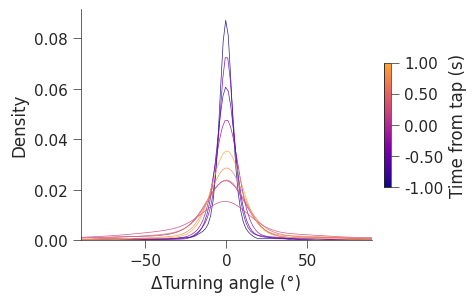

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/S2n - inset


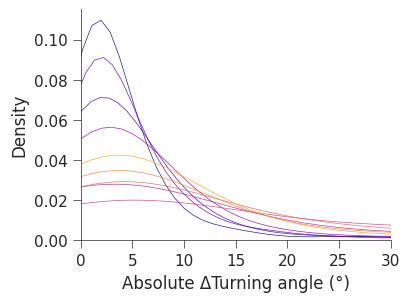

,4fish_data,4fish_means,4fish_stds,4fish_weights,4fish_escape_threshold
0,77.144907,4.760333,3.688282,0.114101,88.07827
1,77.144907,60.058859,22.064022,0.378490,NaN
2,60.095263,115.183970,24.915704,0.344867,NaN
3,77.298792,180.696301,35.277496,0.162542,NaN
4,77.298792,NaN,NaN,NaN,NaN
...,...,...,...,...,...
217795,114.440735,NaN,NaN,NaN,NaN
217796,114.440735,NaN,NaN,NaN,NaN
217797,114.440735,NaN,NaN,NaN,NaN
217798,114.440735,NaN,NaN,NaN,NaN


In [14]:
# pdf
plt.figure(figsize=(4,3))
g = group_sizes[0]
for iw, w_name in enumerate(window_list):
  data = pooled_dtheta[g][w_name]
  if len(data) == 0: continue
  color = cmap(norm(iw))
  sns.kdeplot(data, fill=False, c=color, alpha=0.9, bw_method=None, bw_adjust=1, cut=1, lw=0.5)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # required for older matplotlib versions

cbar = plt.colorbar(sm, ax=plt.gcf().axes, fraction=0.02, pad=0.04)
tick_locs = np.linspace(0, n_w-1, 5)
tick_labels = [f"{list(window_times.values())[int(i)][0]:.2f}" for i in tick_locs]

cbar.set_ticks(tick_locs); cbar.set_ticklabels(tick_labels); cbar.set_label('Time from tap (s)')
plt.xlabel('ΔTurning angle (°)'); plt.ylabel('Density')
plt.xlim(-90,90)
sns.despine();
subpanel = 'S2n - full'
print(figure_path+subpanel)
# plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight');
plt.show()

# inset
plt.figure(figsize=(4,3))
g = group_sizes[0]
for iw, w_name in enumerate(window_list):
  data = np.abs(pooled_dtheta[g][w_name])
  if len(data) == 0: continue
  color = cmap(norm(iw))
  sns.kdeplot(data, fill=False, c=color, alpha=0.9, bw_method=None, bw_adjust=1, cut=1, lw=0.5)

plt.xlabel('Absolute ΔTurning angle (°)'); plt.ylabel('Density')
plt.xlim(0,30); sns.despine()
subpanel = 'S2n - inset'
print(figure_path+subpanel)
# plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight');
plt.show()

# save source data into csv
series_dict = {}
for iw, w_name in enumerate(window_times):
  data = pooled_dtheta[g][w_name]
  col_name = f"{w_name}"
  series_dict[col_name] = pd.Series(data)

df = pd.DataFrame(series_dict)
display(df)
subpanel = 'S2n'
df.to_csv(csv_path+subpanel+'.csv', index=False)

## S2o - turning CDF

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/S2o


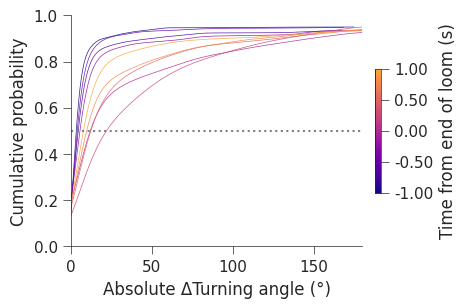

,-1.00s,-0.75s,-0.50s,-0.25s,0.00s,0.25s,0.50s,0.75s,1.00s
0,-53.269300,59.088871,-17.519663,11.566618,70.414128,-148.711659,-6.919622,-1.332890,-1.162980
1,-55.610094,65.850268,-18.073994,8.219343,60.245684,-150.074600,-4.630913,-2.216783,-2.216086
2,-55.344370,67.501875,-18.330325,3.614299,45.247729,-151.220972,-3.442711,-3.131704,-3.494605
3,-52.558629,63.695815,-18.274245,-1.279104,29.928049,137.152724,-4.136926,-2.753325,-3.322502
4,-47.774553,54.402293,-18.288628,-4.211672,16.822013,64.587650,-8.658405,-0.950600,-1.850579
...,...,...,...,...,...,...,...,...,...
1495,-6.092392,NaN,NaN,NaN,NaN,NaN,NaN,4.016792,NaN
1496,-10.140774,NaN,NaN,NaN,NaN,NaN,NaN,7.079274,NaN
1497,-9.777843,NaN,NaN,NaN,NaN,NaN,NaN,10.610612,NaN
1498,-6.074995,NaN,NaN,NaN,NaN,NaN,NaN,12.415074,NaN


In [17]:
from scipy.special import ndtr
from scipy.stats import gaussian_kde

# cdf
plt.figure(figsize=(4,3))
g = group_sizes[0]
for iw, w_name in enumerate(window_list):
  data = np.abs(pooled_dtheta[g][w_name])
  if len(data) == 0: continue
  color = cmap(norm(iw))
  sns.kdeplot(data, fill=False, c=color, alpha=0.9, cumulative=True, cut=1, lw=0.5)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # required for older matplotlib versions

cbar = plt.colorbar(sm, ax=plt.gcf().axes, fraction=0.02, pad=0.04)
tick_locs = np.linspace(0, n_w-1, 5)
tick_labels = [f"{list(window_times.values())[int(i)][0]:.2f}" for i in tick_locs]

cbar.set_ticks(tick_locs); cbar.set_ticklabels(tick_labels); cbar.set_label('Time from end of loom (s)')
plt.xlabel('Absolute ΔTurning angle (°)'); plt.ylabel('Cumulative probability')
plt.xlim(0,180); plt.axhline(0.5,ls=':',color='grey')
sns.despine();
subpanel = 'S2o'
print(figure_path+subpanel)
# plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight');
plt.show()

# save source data into csv
series_dict = {}
for iw, w_name in enumerate(window_times):
  data = pooled_dtheta[g][w_name]
  col_name = f"{w_name}"
  series_dict[col_name] = pd.Series(data)

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# S2p - (100ms)

In [18]:
# take dtheta from each fish for metric
group_sizes = [4]; group_values = {n: [] for n in group_sizes}
hex_colors = ['#1764ab']

dt_sec = 0.05  # sampling interval for delta heading
fps = 121      # frames per second (adjust as needed)

# stimulus-relative windows (in sec)
window_times = {f'{i:.2f}s':(i,i+0.1) for i in np.arange(-1,1.1,0.1)}

# prepare pooling structure
pooled_dtheta = {g: {w: [] for w in window_times} for g in group_sizes}
metrics = {g: {w: [] for w in window_times} for g in group_sizes}

for exp in experiments:
  load_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp]
  if fish_num not in group_sizes: continue

  # load heading data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  f_heading = data['f_heading']  # shape: fish_num x frame_num

  # load stimulus frame
  data = np.load(load_path + 'lev0_tap.npz', allow_pickle=True)
  tap_frame = data['tap_frames'][0]

  # convert delta_t to frames
  dt = int(np.round(dt_sec * fps))
  # per-experiment metrics container
  metrics_exp = {w: {'iqr': [],'median': [], 'p90': [], 'exp': exp} for w in window_times}

  # loop over windows
  for w_name, (t_start, t_end) in window_times.items():
    # compute start and stop frame indices relative to tap
    i0 = tap_frame + int(t_start * fps)
    i1 = tap_frame + int(t_end * fps)

    # collect |Δθ| for all fish in this experiment
    for f in range(fish_num):
      theta = f_heading[f, i0:i1]
      if len(theta) <= dt: continue
      # # wrapped delta heading in degrees
      dtheta = (theta[dt:] - theta[:-dt] + 180) % 360 - 180
      # abs_dtheta = np.abs(dtheta)
      pooled_dtheta[fish_num][w_name].append(dtheta)

      # compute metrics per fish
      if len(dtheta)==0 : continue
      abs_dtheta = np.abs(dtheta)
      metrics_exp[w_name]['iqr'].append(np.percentile(dtheta, 75) - np.percentile(dtheta, 25))
      metrics_exp[w_name]['p90'].append(np.percentile(abs_dtheta, 90))
      metrics_exp[w_name]['median'].append(np.median(abs_dtheta))

  # append per experiment metrics to group-level
  for w_name in window_times:
    metrics[fish_num][w_name].append(metrics_exp[w_name])

# after looping over all experiments, concatenate samples across experiments/fish
for g in pooled_dtheta:
  for w_name, _ in window_times.items():
    if pooled_dtheta[g][w_name]:  # avoid empty lists
      pooled_dtheta[g][w_name] = np.concatenate(pooled_dtheta[g][w_name])
    else:
      pooled_dtheta[g][w_name] = np.array([])

# map window index to a continuous scale
window_list = list(window_times.keys())
n_w = len(window_list)
norm = mpl.colors.Normalize(vmin=0, vmax=n_w-1)
original_cmap = plt.get_cmap('plasma')
colors = original_cmap(np.linspace(0, 0.8, 256))
cmap = mcolors.ListedColormap(colors)

## S2p - median of CDF

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/S2p


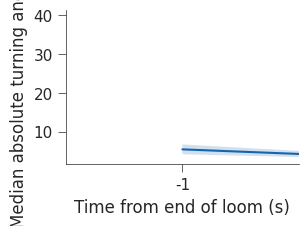

,-1.00s,-0.90s,-0.80s,-0.70s,-0.60s,-0.50s,-0.40s,-0.30s,-0.20s,-0.10s,...,0.10s,0.20s,0.30s,0.40s,0.50s,0.60s,0.70s,0.80s,0.90s,1.00s
0,52.558629,5.504930,26.638298,2.384650,11.515895,18.281436,12.719959,9.598867,3.309328,5.141195,...,7.193089,139.357354,8.079983,59.883579,5.775267,87.980758,2.432929,3.619756,1.637348,1.850579
1,1.906626,1.978463,0.690990,2.380621,1.667317,7.278125,16.441699,7.272886,5.181629,5.035197,...,0.656471,23.613224,7.305328,0.248116,1.073195,23.010853,4.163589,1.278372,84.986180,1.796877
2,11.221081,1.450435,6.828922,5.455695,8.837800,1.887881,2.073453,7.694318,6.720613,2.473567,...,13.664522,18.686288,8.275006,38.091430,16.034743,4.031551,3.162243,1.611524,42.600282,5.975106
3,4.008002,1.188470,0.681855,2.972454,11.256616,2.104016,1.350566,74.610342,8.142691,4.350352,...,2.183575,95.754814,11.400232,21.391554,4.858476,12.620404,97.849203,1.656763,23.532259,8.199833
4,6.744627,6.053352,2.392840,0.658824,2.234329,2.932031,49.756584,75.881518,1.881154,108.202393,...,0.631261,33.685438,0.295104,2.183239,0.948342,2.717456,7.062615,0.804067,1.931185,0.893277
5,4.472168,11.117461,13.987097,10.341749,5.492783,7.495623,3.242902,14.791606,3.172118,0.802280,...,13.880782,8.816625,4.901278,16.515572,72.997727,23.086385,2.920277,41.596240,3.431454,5.871043
6,1.486667,4.307998,0.087947,1.642050,0.681300,0.710598,1.712241,2.612400,0.328039,1.796807,...,1.776703,5.675464,60.659942,3.752998,1.132762,0.615600,1.429723,1.728912,3.340752,0.444411
7,1.347115,2.264400,77.345236,0.972486,1.621614,2.516000,0.291952,75.612483,2.300737,0.944036,...,89.070032,34.548690,1.691674,114.573348,3.033902,2.815032,3.951500,0.757333,6.982680,1.183102
8,4.111112,0.701487,5.771228,0.704215,32.345520,7.916656,20.250573,13.442363,6.488525,12.641686,...,27.171344,21.456130,85.182861,28.129551,19.433370,149.890603,77.247664,15.804097,8.097907,31.238125
9,3.272515,2.029743,2.613591,10.798969,2.996954,13.501642,4.758554,6.015219,9.032401,6.511734,...,30.165527,40.816360,5.050240,3.280614,6.984763,2.052659,0.938301,38.150885,1.147669,4.341287


In [19]:
# metric
metric_name = 'median'; ylabel = 'Median absolute turning angle (°)'

# --- plot ---
plt.figure(figsize=(3,2))
for ig, g in enumerate(group_sizes):
  means = [np.mean([d[metric_name] for d in metrics[g][w]]) for w in window_times]
  sems = [stats.sem(np.concatenate([d[metric_name] for d in metrics[g][w]])) for w in window_times]
  plt.plot(means, color=hex_colors[ig], label=f'{g}-fish')
  plt.fill_between(np.arange(len(means)), [m-s for m, s in zip(means,sems)], [m+s for m, s in zip(means,sems)],\
                   color=hex_colors[ig], alpha=0.2, linewidth=0)
plt.ylabel(ylabel); plt.xlabel('Time from end of loom (s)')
plt.xticks([0,5,9,14,19],['-1','-0.5','0','0.5','1'])
plt.axvline(9,c='grey',linewidth=0.5, alpha=0.7); plt.xlim(-1,1)
sns.despine();
subpanel = 'S2p'
print(figure_path+subpanel)
# plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight');
plt.show()

# save source data into csv
series_dict = {}
for iw, w_name in enumerate(window_times):
  col_name = f"{w_name}"; tmp = []
  for m in metrics[g][w_name]:
    [tmp.append(entry) for entry in m[metric_name]]
  series_dict[col_name] = pd.Series(tmp)

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# S2q - Δ speed time series (tap vs loom)

In [ ]:
# setup
stimulus_types = ['Tap', 'Loom']
group_values = {n: [] for n in stimulus_types}
hex_colors = ['#1764ab', '#61409b']
window_of_interest = [1] # in sec

# directories for the data and analysis
gsheet = 'https://docs.google.com/spreadsheets/d/1zJNHJJECC8FGB9S8tIh6QnoRihyoTZyKAgS-SE8ojwU/edit?gid=1421697431#gid=1421697431'

## load tap data
tab_name = 'tap_gsize'
experiment_class = 'Tap escape - group size'
path = account_path + 'Yu_escape_paper/Behavior/' + experiment_class
data_path = path + '/Data/'; save_path = path + '/Analysis/'
metadata = read_metadata(gsheet,tab_name)
experiments = metadata.index

for exp in experiments[::]:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp];
  if fish_num !=4: continue

  # load data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  scale, fps, frame_num =  data['scale'], data['fps'], data['frame_num']
  f_bodylength_mm = data['f_bodylength_mm']
  f_speed = data['f_speed']*scale

  data = np.load(load_path + 'lev0_tap.npz', allow_pickle=True)
  tap = data['tap_frames'][0]

  # append real data
  for f in range(fish_num):
    group_values['Tap'].append((f_speed[f][tap-int(30*121):tap+int(30*121)])-np.mean(f_speed[f][tap-int(30*121):tap]))

# load loom data
tab_name = 'loom_gsize'
experiment_class = 'Loom escape - group size'
path = account_path + 'Yu_escape_paper/Behavior/' + experiment_class
data_path = path + '/Data/'; save_path = path + '/Analysis/'
metadata = read_metadata(gsheet,tab_name)
experiments = metadata.index

# loop through escape
for exp in experiments[::]:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp];
  if fish_num !=4: continue

  # load data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  scale, fps, frame_num =  data['scale'], data['fps'], data['frame_num']
  f_bodylength_mm = data['f_bodylength_mm']
  f_speed = data['f_speed']*scale

  data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
  loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len

  # append real data
  for f in range(fish_num):
    group_values['Loom'].append((f_speed[f][loom_off-int(30*121):loom_off+int(30*121)])-np.mean(f_speed[f][loom_off-int(30*121):loom_off]))

,experiment,fish_num,rig_mm,vid_px
0,jjm_20240223_s0,1,350,959
1,jjm_20240223_s1,1,350,959
2,jjm_20240223_s2,1,350,959
3,jjm_20240223_s3,1,350,959
4,jjm_20240226_s0_redo0223,1,350,947
...,...,...,...,...
70,jjm_20240313_s10,8,350,975
71,jjm_20240313_s11,8,350,975
72,jjm_20240313_s12,8,350,975
73,jjm_20240321-2_s3,8,350,968


,experiment,fish_num,rig_mm,vid_px,rig_coord,loomX,loomZ,loom_dur
0,jy_240311_s16,1,265,945,"25,27;981,27;981,977;25,977",15,-30,6
1,jy_240311_s18,1,265,945,"25,27;981,27;981,977;25,977",15,-30,4
2,jy_240318_s20,1,265,927,"28,43;967,43;967,977;28,977",-15,30,5
3,jy_240318_s21,1,265,927,"28,43;967,43;967,977;28,977",-15,-30,3
4,jy_240318_s22,1,265,927,"28,43;967,43;967,977;28,977",-15,30,4
...,...,...,...,...,...,...,...,...
93,jy_240516_s10,8,265,904,"48,51;965,51;965,955;48,955",15,-30,3
94,jy_240516_s11,8,265,904,"48,51;965,51;965,955;48,955",15,30,3
95,jy_240516_s12,8,265,904,"48,51;965,51;965,955;48,955",-15,-30,3
96,jy_240516_s13,8,265,904,"48,51;965,51;965,955;48,955",-15,30,5


/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S2q


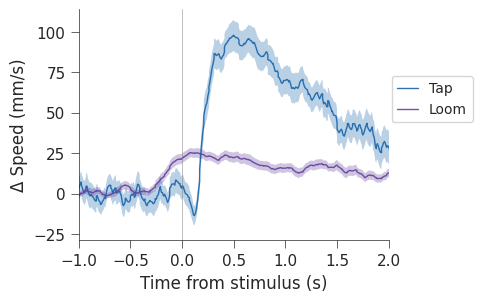

N = [15, 20]


,Tap_1,Tap_2,Tap_3,Tap_4,Tap_5,Tap_6,Tap_7,Tap_8,Tap_9,Tap_10,...,Loom_71,Loom_72,Loom_73,Loom_74,Loom_75,Loom_76,Loom_77,Loom_78,Loom_79,Loom_80
0,33.817374,46.935409,62.203353,12.085018,43.341978,-17.621582,-12.217934,-45.250610,137.236039,18.083635,...,21.812726,-2.090027,11.134507,1.169258,-6.542166,-3.490020,4.518805,-17.795778,-11.312310,8.207481
1,20.864458,18.236286,85.950577,11.511902,21.821944,-18.197223,-11.836339,-18.970850,131.189450,17.942892,...,26.746360,-3.347276,9.187858,4.202389,-6.598253,-4.969284,9.750820,-17.905938,-19.795455,5.371127
2,20.864458,18.385497,103.869308,-5.221816,19.128264,-18.455073,-30.377521,-19.845500,122.983967,10.404634,...,27.546516,-4.886813,7.923905,6.801639,-6.058746,-5.946026,14.013376,-18.016091,-28.382392,3.153693
3,20.864458,21.705088,121.121735,-5.366844,18.457734,-18.237645,-49.362262,-19.406847,102.454654,-5.996006,...,28.346672,-6.708637,6.564212,8.967009,-4.923645,-3.870356,17.118720,-18.016565,-28.796149,3.186658
4,20.864458,22.525666,121.866614,-21.058975,0.907889,-17.420488,-68.906475,-20.429977,95.316194,-21.873342,...,28.794130,-8.812749,5.108778,10.698499,-4.474264,-0.219444,19.470526,-19.276430,-29.484569,3.478821
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,44.812747,36.469143,80.177413,145.936702,-58.649752,-54.129179,108.283730,-25.661786,40.107239,31.390508,...,21.176479,-24.751704,-7.210211,-8.677507,-9.027154,-12.385360,-18.556472,-2.173839,-26.546242,-5.886227
359,44.056417,38.133656,100.886511,144.436316,-58.462449,-54.332361,106.710205,-25.874032,40.186016,47.539690,...,21.062269,-24.993584,-4.873314,-6.147918,-9.398042,-10.596234,-18.256789,-2.823004,-27.162190,-6.635831
360,43.460852,21.954607,124.788145,142.106954,-57.615359,-55.169206,83.735890,-26.670897,42.682401,48.523970,...,20.948060,-24.054460,-2.238040,-2.698642,-10.171368,-8.559232,-18.967547,-6.036724,-27.599812,-8.656578
361,45.957565,-4.343175,147.468372,136.298794,-58.162634,-55.272875,62.984427,-27.235730,45.302550,31.653599,...,20.833850,-23.488504,0.695611,1.670318,-11.347133,-6.150234,-19.441177,-7.224772,-28.479030,-11.126540


In [ ]:
subpanel = 'S2q'
# make time_sec relative to loom_off for plotting
pre = np.linspace(-30,0,30*121); post = np.linspace(0,30,30*121)
rel_time = np.concatenate((pre,post)); rel_sec = np.round(rel_time,2)

# PLOT # mean+sem
plt.figure(figsize=[4,3])
for i, gs in enumerate(stimulus_types):
  # Plot real data
  plt.plot(rel_sec,np.mean(group_values[gs],axis=0),linewidth=1,c=hex_colors[i],alpha=0.9,label=gs)
  plt.fill_between(rel_sec, np.mean(group_values[gs],axis=0)-scipy.stats.sem(group_values[gs],axis=0), \
                    np.mean(group_values[gs],axis=0)+scipy.stats.sem(group_values[gs],axis=0),color=hex_colors[i],alpha=0.3,linewidth=0)

plt.axvline(0,c='grey',linewidth=0.5, alpha=0.7)
plt.legend(bbox_to_anchor=(1,0.5),handlelength=1.5,markerscale=0.7,borderaxespad=0.2,fontsize=10)
plt.xlim(-1,2); # plt.ylim(0.75,1.9);
plt.xlabel('Time from stimulus (s)'); plt.ylabel('Δ Speed (mm/s)')
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight');
plt.show()

print(f"N = {[int(len(group_values[g])/4) for g in stimulus_types]}")

# save source data into csv - for time series, save out the visible part
ST, ED = -30, 30; st, ed = -1, 2; fps = 121

series_dict = {}
for group, samples in group_values.items():
  for i, sample in enumerate(samples):
    col_name = f"{group}_{i+1}"
    series_dict[col_name] = pd.Series(sample[(st-ST)*fps:(ed-ST)*fps])

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# S2r - speed time series (tap vs loom)

In [ ]:
# setup
stimulus_types = ['Tap', 'Loom']
group_values = {n: [] for n in stimulus_types}
hex_colors = ['#1764ab', '#61409b']
window_of_interest = [1] # in sec

# directories for the data and analysis
gsheet = 'https://docs.google.com/spreadsheets/d/1zJNHJJECC8FGB9S8tIh6QnoRihyoTZyKAgS-SE8ojwU/edit?gid=1421697431#gid=1421697431'

## load tap data
tab_name = 'tap_gsize'
experiment_class = 'Tap escape - group size'
path = account_path + 'Yu_escape_paper/Behavior/' + experiment_class
data_path = path + '/Data/'; save_path = path + '/Analysis/'
metadata = read_metadata(gsheet,tab_name)
experiments = metadata.index

for exp in experiments[::]:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp];
  if fish_num !=4: continue

  # load data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  scale, fps, frame_num =  data['scale'], data['fps'], data['frame_num']
  f_bodylength_mm = data['f_bodylength_mm']
  f_speed = data['f_speed']*scale

  data = np.load(load_path + 'lev0_tap.npz', allow_pickle=True)
  tap = data['tap_frames'][0]

  # append real data
  for f in range(fish_num): group_values['Tap'].append(f_speed[f][tap-int(30*121):tap+int(30*121)])

# load loom data
tab_name = 'loom_gsize'
experiment_class = 'Loom escape - group size'
path = account_path + 'Yu_escape_paper/Behavior/' + experiment_class
data_path = path + '/Data/'; save_path = path + '/Analysis/'
metadata = read_metadata(gsheet,tab_name)
experiments = metadata.index

# loop through escape
for exp in experiments[::]:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp];
  if fish_num !=4: continue

  # load data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  scale, fps, frame_num =  data['scale'], data['fps'], data['frame_num']
  f_bodylength_mm = data['f_bodylength_mm']
  f_speed = data['f_speed']*scale

  data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
  loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len

  # append real data
  for f in range(fish_num): group_values['Loom'].append(f_speed[f][loom_off-int(30*121):loom_off+int(30*121)])

,experiment,fish_num,rig_mm,vid_px
0,jjm_20240223_s0,1,350,959
1,jjm_20240223_s1,1,350,959
2,jjm_20240223_s2,1,350,959
3,jjm_20240223_s3,1,350,959
4,jjm_20240226_s0_redo0223,1,350,947
...,...,...,...,...
70,jjm_20240313_s10,8,350,975
71,jjm_20240313_s11,8,350,975
72,jjm_20240313_s12,8,350,975
73,jjm_20240321-2_s3,8,350,968


,experiment,fish_num,rig_mm,vid_px,rig_coord,loomX,loomZ,loom_dur
0,jy_240311_s16,1,265,945,"25,27;981,27;981,977;25,977",15,-30,6
1,jy_240311_s18,1,265,945,"25,27;981,27;981,977;25,977",15,-30,4
2,jy_240318_s20,1,265,927,"28,43;967,43;967,977;28,977",-15,30,5
3,jy_240318_s21,1,265,927,"28,43;967,43;967,977;28,977",-15,-30,3
4,jy_240318_s22,1,265,927,"28,43;967,43;967,977;28,977",-15,30,4
...,...,...,...,...,...,...,...,...
93,jy_240516_s10,8,265,904,"48,51;965,51;965,955;48,955",15,-30,3
94,jy_240516_s11,8,265,904,"48,51;965,51;965,955;48,955",15,30,3
95,jy_240516_s12,8,265,904,"48,51;965,51;965,955;48,955",-15,-30,3
96,jy_240516_s13,8,265,904,"48,51;965,51;965,955;48,955",-15,30,5


/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S2r


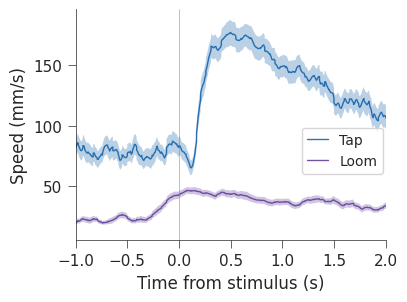

N = [15, 20]


,Tap_1,Tap_2,Tap_3,Tap_4,Tap_5,Tap_6,Tap_7,Tap_8,Tap_9,Tap_10,...,Loom_71,Loom_72,Loom_73,Loom_74,Loom_75,Loom_76,Loom_77,Loom_78,Loom_79,Loom_80
0,97.026120,121.306673,132.693460,105.773519,110.474364,47.608679,61.586420,41.837794,224.102255,81.050247,...,49.008685,30.803016,47.664492,28.580606,27.853333,27.562357,29.422069,3.529051,24.561010,27.952563
1,84.073205,92.607550,156.440684,105.200404,88.954330,47.033038,61.968015,68.117554,218.055666,80.909503,...,53.942320,29.545768,45.717843,31.613737,27.797246,26.083093,34.654084,3.418890,16.077866,25.116209
2,84.073205,92.756761,174.359415,88.466685,86.260650,46.775188,43.426832,67.242904,209.850183,73.371245,...,54.742475,28.006231,44.453890,34.212987,28.336753,25.106351,38.916639,3.308738,7.490928,22.898775
3,84.073205,96.076352,191.611841,88.321657,85.590120,46.992616,24.442092,67.681557,189.320870,56.970605,...,55.542631,26.184407,43.094197,36.378357,29.471854,27.182021,42.021984,3.308264,7.077172,22.931740
4,84.073205,96.896930,192.356720,72.629526,68.040276,47.809773,4.897879,66.658427,182.182411,41.093270,...,55.990090,24.080294,41.638764,38.109847,29.921234,30.832933,44.373789,2.048399,6.388751,23.223903
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,108.021493,110.840407,150.667520,239.625203,8.482634,11.101082,182.088084,61.426618,126.973456,94.357120,...,48.372438,8.141340,29.319775,18.733840,25.368345,18.667017,6.346792,19.150990,9.327079,13.858855
359,107.265164,112.504919,171.376618,238.124817,8.669937,10.897900,180.514558,61.214373,127.052233,110.506302,...,48.258229,7.899460,31.656672,21.263430,24.997457,20.456143,6.646475,18.501825,8.711130,13.109251
360,106.669599,96.325871,195.278252,235.795455,9.517027,10.061055,157.540244,60.417507,129.548617,111.490581,...,48.144019,8.838584,34.291946,24.712705,24.224130,22.493145,5.935717,15.288105,8.273508,11.088504
361,109.166311,70.028089,217.958479,229.987295,8.969752,9.957386,136.788780,59.852674,132.168767,94.620210,...,48.029810,9.404540,37.225597,29.081666,23.048365,24.902143,5.462087,14.100057,7.394290,8.618542


In [ ]:
subpanel = 'S2r'
# make time_sec relative to loom_off for plotting
pre = np.linspace(-30,0,30*121); post = np.linspace(0,30,30*121)
rel_time = np.concatenate((pre,post)); rel_sec = np.round(rel_time,2)

# PLOT # mean+sem
plt.figure(figsize=[4,3])
for i, gs in enumerate(stimulus_types):
  # Plot real data
  plt.plot(rel_sec,np.mean(group_values[gs],axis=0),linewidth=1,c=hex_colors[i],alpha=0.9,label=gs)
  plt.fill_between(rel_sec, np.mean(group_values[gs],axis=0)-scipy.stats.sem(group_values[gs],axis=0), \
                    np.mean(group_values[gs],axis=0)+scipy.stats.sem(group_values[gs],axis=0),color=hex_colors[i],alpha=0.3,linewidth=0)

plt.axvline(0,c='grey',linewidth=0.5, alpha=0.7)
plt.legend(bbox_to_anchor=(1,0.5),handlelength=1.5,markerscale=0.7,borderaxespad=0.2,fontsize=10)
plt.xlim(-1,2); # plt.ylim(0.75,1.9);
plt.xlabel('Time from stimulus (s)'); plt.ylabel('Speed (mm/s)')
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight');
plt.show()

print(f"N = {[int(len(group_values[g])/4) for g in stimulus_types]}")

# save source data into csv - for time series, save out the visible part
ST, ED = -30, 30; st, ed = -1, 2; fps = 121

series_dict = {}
for group, samples in group_values.items():
  for i, sample in enumerate(samples):
    col_name = f"{group}_{i+1}"
    series_dict[col_name] = pd.Series(sample[(st-ST)*fps:(ed-ST)*fps])

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

# S2s - iid (bd) time series (tap vs loom)

In [ ]:
# setup
stimulus_types = ['Tap', 'Loom']
group_values = {n: [] for n in stimulus_types}
hex_colors = ['#1764ab', '#61409b']
window_of_interest = [1] # in sec

# directories for the data and analysis
gsheet = 'https://docs.google.com/spreadsheets/d/1zJNHJJECC8FGB9S8tIh6QnoRihyoTZyKAgS-SE8ojwU/edit?gid=1421697431#gid=1421697431'

## load tap data
tab_name = 'tap_gsize'
experiment_class = 'Tap escape - group size'
path = account_path + 'Yu_escape_paper/Behavior/' + experiment_class
data_path = path + '/Data/'; save_path = path + '/Analysis/'
metadata = read_metadata(gsheet,tab_name)
experiments = metadata.index

for exp in experiments[::]:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp];
  if fish_num !=4: continue

  # load data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  scale, fps, frame_num =  data['scale'], data['fps'], data['frame_num']
  f_bodylength_mm = data['f_bodylength_mm']

  data = np.load(load_path + 'lev0_group_basics.npz', allow_pickle=True)
  f_IID = data['f_IID'] # in mm
  f_IID_bd = f_IID/np.mean(f_bodylength_mm)

  data = np.load(load_path + 'lev0_tap.npz', allow_pickle=True)
  tap = data['tap_frames'][0]

  # get change btw pre and post tap
  window = int(fps*window_of_interest); dt = 1/fps;
  delta = [np.mean(t[tap:tap+window]) for t in f_IID_bd] # mean

  # append real data
  pair_num = f_IID.shape[0]
  for f in range(pair_num): group_values['Tap'].append(f_IID_bd[f][tap-int(30*121):tap+int(30*121)])

# load loom data
tab_name = 'loom_gsize'
experiment_class = 'Loom escape - group size'
path = account_path + 'Yu_escape_paper/Behavior/' + experiment_class
data_path = path + '/Data/'; save_path = path + '/Analysis/'
metadata = read_metadata(gsheet,tab_name)
experiments = metadata.index

# loop through escape
for exp in experiments[::]:
  load_path = save_path + exp + '/'; output_path = save_path + exp + '/'
  fish_num = metadata.fish_num[exp];
  if fish_num !=4: continue

  # load data
  data = np.load(load_path + 'lev0_basics.npz', allow_pickle=True)
  scale, fps, frame_num =  data['scale'], data['fps'], data['frame_num']
  f_bodylength_mm = data['f_bodylength_mm']

  data = np.load(load_path + 'lev0_group_basics.npz', allow_pickle=True)
  f_IID = data['f_IID'] # in mm
  f_IID_bd = f_IID/np.mean(f_bodylength_mm)

  data = np.load(load_path + 'lev0_loom.npz', allow_pickle=True)
  loom_on, loom_len = data['loom_frames'][0], data['loom_len']; loom_off = loom_on + loom_len

  # get change btw pre and post tap
  window = int(fps*window_of_interest); dt = 1/fps;
  delta = [np.mean(t[loom_off:loom_off+window]) for t in f_IID_bd] # mean

  # append real data
  pair_num = f_IID.shape[0]
  for f in range(pair_num): group_values['Loom'].append(f_IID_bd[f][loom_off-int(30*121):loom_off+int(30*121)])

,experiment,fish_num,rig_mm,vid_px
0,jjm_20240223_s0,1,350,959
1,jjm_20240223_s1,1,350,959
2,jjm_20240223_s2,1,350,959
3,jjm_20240223_s3,1,350,959
4,jjm_20240226_s0_redo0223,1,350,947
...,...,...,...,...
70,jjm_20240313_s10,8,350,975
71,jjm_20240313_s11,8,350,975
72,jjm_20240313_s12,8,350,975
73,jjm_20240321-2_s3,8,350,968


/tmp/ipykernel_12253/2027799047.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  window = int(fps*window_of_interest); dt = 1/fps;


,experiment,fish_num,rig_mm,vid_px,rig_coord,loomX,loomZ,loom_dur
0,jy_240311_s16,1,265,945,"25,27;981,27;981,977;25,977",15,-30,6
1,jy_240311_s18,1,265,945,"25,27;981,27;981,977;25,977",15,-30,4
2,jy_240318_s20,1,265,927,"28,43;967,43;967,977;28,977",-15,30,5
3,jy_240318_s21,1,265,927,"28,43;967,43;967,977;28,977",-15,-30,3
4,jy_240318_s22,1,265,927,"28,43;967,43;967,977;28,977",-15,30,4
...,...,...,...,...,...,...,...,...
93,jy_240516_s10,8,265,904,"48,51;965,51;965,955;48,955",15,-30,3
94,jy_240516_s11,8,265,904,"48,51;965,51;965,955;48,955",15,30,3
95,jy_240516_s12,8,265,904,"48,51;965,51;965,955;48,955",-15,-30,3
96,jy_240516_s13,8,265,904,"48,51;965,51;965,955;48,955",-15,30,5


/tmp/ipykernel_12253/2027799047.py:70: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  window = int(fps*window_of_interest); dt = 1/fps;


/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S2s


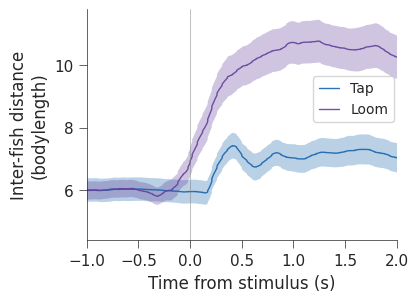

N = [15, 20]


,Tap_1,Tap_2,Tap_3,Tap_4,Tap_5,Tap_6,Tap_7,Tap_8,Tap_9,Tap_10,...,Loom_111,Loom_112,Loom_113,Loom_114,Loom_115,Loom_116,Loom_117,Loom_118,Loom_119,Loom_120
0,4.947161,5.163973,0.602515,2.748075,4.690694,4.652874,4.897061,9.404073,1.325435,5.164521,...,4.127534,7.323985,9.784542,2.836944,8.886820,9.500217,2.740966,4.267784,9.166031,8.493265
1,4.982529,5.176560,0.606048,2.798982,4.730587,4.663403,4.919291,9.415713,1.336752,5.175171,...,4.141361,7.299711,9.755424,2.849144,8.919623,9.496945,2.673704,4.265608,9.168533,8.494588
2,5.001730,5.178919,0.614957,2.834976,4.737798,4.651097,4.923305,9.415522,1.339563,5.186294,...,4.138190,7.267744,9.726533,2.855699,8.950428,9.498219,2.624806,4.264026,9.171983,8.494646
3,5.021433,5.195198,0.618052,2.866238,4.758890,4.664837,4.923652,9.415432,1.341580,5.188440,...,4.138902,7.235759,9.695268,2.861075,9.007507,9.520404,2.588554,4.262205,9.185519,8.496883
4,5.040726,5.233851,0.621339,2.905096,4.780204,4.701138,4.925610,9.416412,1.332886,5.189386,...,4.122292,7.231780,9.694308,2.860606,9.056421,9.564833,2.571296,4.265747,9.199689,8.520447
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,2.135662,5.988656,5.691299,5.974940,5.506298,0.606397,5.900805,3.839688,3.253559,3.217774,...,5.566128,5.527953,2.428756,5.929793,3.039835,8.901865,2.782258,6.232859,3.329100,9.468207
359,2.172356,6.010285,5.775436,6.023912,5.602730,0.602994,5.899332,3.800183,3.241864,3.219638,...,5.565684,5.519000,2.448090,5.949376,3.014649,8.901190,2.798491,6.250636,3.335834,9.484910
360,2.173564,6.053352,5.836673,6.039040,5.641218,0.582457,5.898641,3.783722,3.231454,3.211604,...,5.527071,5.512819,2.445009,5.953620,2.990697,8.900115,2.798493,6.267414,3.323996,9.484045
361,2.157035,6.097059,5.880815,6.031081,5.639907,0.571193,5.898552,3.779052,3.221207,3.188185,...,5.481380,5.512664,2.423223,5.956217,2.965725,8.899054,2.800074,6.285776,3.312338,9.484618


In [ ]:
subpanel = 'S2s'
# make time_sec relative to loom_off for plotting
pre = np.linspace(-30,0,30*121); post = np.linspace(0,30,30*121)
rel_time = np.concatenate((pre,post)); rel_sec = np.round(rel_time,2)

# PLOT # mean+sem
plt.figure(figsize=[4,3])
for i, gs in enumerate(stimulus_types):
  # Plot real data
  plt.plot(rel_sec,np.mean(group_values[gs],axis=0),linewidth=1,c=hex_colors[i],alpha=0.9,label=gs)
  plt.fill_between(rel_sec, np.mean(group_values[gs],axis=0)-scipy.stats.sem(group_values[gs],axis=0), \
                    np.mean(group_values[gs],axis=0)+scipy.stats.sem(group_values[gs],axis=0),color=hex_colors[i],alpha=0.3,linewidth=0)

plt.axvline(0,c='grey',linewidth=0.5, alpha=0.7)
plt.legend(bbox_to_anchor=(1,0.5),handlelength=1.5,markerscale=0.7,borderaxespad=0.2,fontsize=10)
plt.xlim(-1,2); # plt.ylim(0.75,1.9);
plt.xlabel('Time from stimulus (s)'); plt.ylabel('Inter-fish distance\n(bodylength)')
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight');
plt.show()

print(f"N = {[int(len(group_values[g])/math.comb(4,2)) for g in stimulus_types]}")

# save source data into csv - for time series, save out the visible part
ST, ED = -30, 30; st, ed = -1, 2; fps = 121

series_dict = {}
for group, samples in group_values.items():
  for i, sample in enumerate(samples):
    col_name = f"{group}_{i+1}"
    series_dict[col_name] = pd.Series(sample[(st-ST)*fps:(ed-ST)*fps])

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)